## Тест
Важно, чтобы сервер был поднят на astro_env и тянул оттуда все импорты

In [1]:
import sys
print(sys.executable)

/Users/zuha/Desktop/FKI/4 курс 2025-2026/course_work-SBF/astro_env/bin/python3


In [2]:
import argparse, numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time
import builtins
from pathlib import Path
from astropy.io import fits
from astropy.wcs import WCS
from astropy.stats import sigma_clipped_stats
from scipy.ndimage import gaussian_filter
from scipy import ndimage
from scipy.signal import fftconvolve
from astropy.convolution import Gaussian2DKernel, interpolate_replace_nans
from photutils.isophote import Ellipse, EllipseGeometry, build_ellipse_model
from photutils.segmentation import detect_sources, deblend_sources
import stpsf                                    # PSF под JWST файл
from scipy.fft import fft2, fftfreq, fftshift, set_workers
from photutils.background import Background2D, MedianBackground
from astropy.stats import SigmaClip
from astropy.modeling.models import Sersic2D
from astropy.modeling.fitting import LevMarLSQFitter
# Все print в файле автоматически получают префикс с текущим временем устройства
_orig_print = builtins.print

def print(*args, **kwargs):
    _orig_print(f"[{time.strftime('%H:%M:%S')}]", *args, **kwargs)



In [3]:
# --- жёстко заданные входные файлы ---
f150w_path = Path("../data/NGC 1380/jw03055-o001_t001_nircam_clear-f150w_i2d.fits")
f090w_path = Path("../data/NGC 1380/jw03055-o001_t001_nircam_clear-f090w_i2d.fits")

# --- куда писать результаты ---
out_dir = f150w_path.parent
stem = f150w_path.stem

# --- режимы ---
USE_ISOPHOTE = True
DUMP_ISOPHOTES = True
USE_BKG = True          # для начала лучше False, раз фон пока только мешал
DO_DEBLEND = True       # для начала лучше True, иначе SBF будет сильно испорчен яркими источниками
DRY = False

# --- центр ---
FIXED_CENTER = None      # пример: (6306.0, 2730.0)

# --- background/mask ---
BKG_BOX0 = 256
BKG_BOX2D = 256
BKG_FILTER = 5      # сглаживание карты фона
SIGMA_STAT = 3.0
SIGMA_DET = 2.5
MASK_NPIXELS = 4

# --- isophote ---
HALF_SIZE = 3000
ISO_START_SMA = 50.0
ISO_START_EPS = 0.2
ISO_START_PA = 0.0

# --- FFT / PSF ---
FFT_WORKERS = -1         # -1 = все доступные потоки scipy.fft
PSF_SIZE = 129
PSF_NLAMBDA = 7
PSFREF = None            # если None, считаем PSF по f150w_path



Это бывший load_i2d, но в развёрнутом виде.

In [4]:
print("loading i2d files...")

# F150W
with fits.open(f150w_path, memmap=False) as hdul:
    img_f150 = hdul["SCI"].data.astype(float)
    hdr150 = hdul["SCI"].header
    valid150 = np.isfinite(img_f150)

    if "WHT" in hdul:
        try:
            wht150 = hdul["WHT"].data
            valid150 &= np.isfinite(wht150) & (wht150 > 0)
        except Exception:
            pass

wcs150 = WCS(hdr150)
pixar_sr = float(hdr150["PIXAR_SR"])
pix_area = pixar_sr / 2.350443e-11
print(f"[WCS] PIXAR_SR={pixar_sr:.8e} sr → pix_area={pix_area:.8e} arcsec^2")

# F090W (опционально)
img_f090 = None
hdr090 = None
valid090 = None
wcs090 = None

if f090w_path.exists():
    with fits.open(f090w_path, memmap=False) as hdul:
        img_f090 = hdul["SCI"].data.astype(float)
        hdr090 = hdul["SCI"].header
        valid090 = np.isfinite(img_f090)

        if "WHT" in hdul:
            try:
                wht090 = hdul["WHT"].data
                valid090 &= np.isfinite(wht090) & (wht090 > 0)
            except Exception:
                pass

    wcs090 = WCS(hdr090)

print(f"F150W shape = {img_f150.shape}, valid = {valid150.sum()}")
if img_f090 is not None:
    print(f"F090W shape = {img_f090.shape}, valid = {valid090.sum()}")

[19:39:05] loading i2d files...


Set DATE-AVG to '2023-11-09T21:33:24.076' from MJD-AVG.
Set DATE-END to '2023-11-09T21:52:00.860' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to    23.109100 from OBSGEO-[XYZ].
Set OBSGEO-H to 1523626142.965 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


[19:39:05] [WCS] PIXAR_SR=2.29190411e-14 sr → pix_area=9.75094527e-04 arcsec^2
[19:39:06] F150W shape = (4377, 9876), valid = 33055333
[19:39:06] F090W shape = (4376, 9875), valid = 33051148


Set DATE-AVG to '2023-11-09T19:55:21.653' from MJD-AVG.
Set DATE-END to '2023-11-09T21:10:19.167' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to    23.148810 from OBSGEO-[XYZ].
Set OBSGEO-H to 1522915295.335 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


## Быстрый поиск центра

Это единственная маленькая функция, которую реально стоит оставить. Без неё код в следующих ячейках станет только грязнее.

In [5]:
def guess_center_fast(img, valid, down=4, sigma=3.0, q=99.5, wcs=None, log=True):
    ny, nx = img.shape

    def _log_center(xc, yc, note=""):
        if not log:
            return
        msg = f"[CENTER-FAST] x={xc:.2f}, y={yc:.2f}"
        if note:
            msg += f" ({note})"
        if wcs is not None:
            ra_deg, dec_deg = wcs.pixel_to_world_values(xc, yc)
            msg += f" | RA={ra_deg:.8f} deg, Dec={dec_deg:.8f} deg"
        print(msg)

    img_d = img[::down, ::down]
    val_d = valid[::down, ::down] & np.isfinite(img_d)

    if not np.any(val_d):
        xc, yc = nx / 2.0, ny / 2.0
        _log_center(xc, yc, note="fallback: no valid downsampled pixels")
        return xc, yc

    data = np.where(val_d, img_d, 0.0).astype(np.float32)
    w = val_d.astype(np.float32)

    num = gaussian_filter(data, sigma=sigma)
    den = gaussian_filter(w, sigma=sigma)
    sm = np.divide(num, den, out=np.full_like(num, np.nan), where=den > 1e-6)

    if not np.isfinite(sm).any():
        xc, yc = nx / 2.0, ny / 2.0
        _log_center(xc, yc, note="fallback: sm is all-NaN")
        return xc, yc

    thr = np.nanpercentile(sm, q)
    sel = np.isfinite(sm) & (sm >= thr)

    if sel.sum() < 50:
        y, x = np.unravel_index(np.nanargmax(sm), sm.shape)
        xc, yc = float(x * down), float(y * down)
        _log_center(xc, yc, note="fallback: argmax")
        return xc, yc

    ys, xs = np.nonzero(sel)
    ws = sm[sel] - np.nanmin(sm[sel])
    ws = np.nan_to_num(ws, nan=0.0) + 1e-12

    x0 = float((xs * ws).sum() / ws.sum()) * down
    y0 = float((ys * ws).sum() / ws.sum()) * down
    _log_center(x0, y0, note=f"down={down}, sigma={sigma}, q={q}")
    return x0, y0

## Подготовка кадра и маски

Здесь либо работаем без фона, либо через двухпроходный фон. Это бывший кусок prepare_image_and_mask, но развёрнуто в явный сценарий.

# Очистка фона

In [6]:
print("estimating and subtracting background...")

img0 = np.array(img_f150, copy=True)

# работаем только по валидным пикселям
work0 = np.array(img0, copy=True)
work0[~valid150] = np.nan

if USE_BKG:
    # ------------------------------------------------------------
    # 1. Грубая оценка фона без сложной маски
    # ------------------------------------------------------------
    bkg0 = Background2D(
        work0,
        box_size=BKG_BOX0,
        filter_size=(BKG_FILTER, BKG_FILTER),
        sigma_clip=SigmaClip(sigma=3.0, maxiters=5),
        bkg_estimator=MedianBackground(),
        mask=~valid150,
    )

    bg_scalar = float(np.nanmedian(bkg0.background))
    print(f"[BKG] rough scalar background = {bg_scalar:.3e}")

    img1 = img0 - bg_scalar

    # ------------------------------------------------------------
    # 2. На img1 строим грубую маску источников
    # ------------------------------------------------------------
    det_work = np.array(img1, copy=True)
    det_work[~valid150] = np.nan

    mean_det, med_det, std_det = sigma_clipped_stats(
        det_work[np.isfinite(det_work)],
        sigma=3.0,
        maxiters=5,
    )

    thr_det = med_det + 2.5 * max(std_det, 1e-12)

    segm = detect_sources(
        det_work,
        threshold=thr_det,
        npixels=MASK_NPIXELS,
        connectivity=8,
    )

    src_mask = np.zeros_like(img1, dtype=bool)
    if segm is not None:
        src_mask = segm.data > 0

    # ------------------------------------------------------------
    # 3. Финальная 2D-оценка фона уже с маской источников
    # ------------------------------------------------------------
    final_mask = (~valid150) | src_mask

    bkg2d = Background2D(
        img1,
        box_size=BKG_BOX2D,
        filter_size=(BKG_FILTER, BKG_FILTER),
        sigma_clip=SigmaClip(sigma=3.0, maxiters=5),
        bkg_estimator=MedianBackground(),
        mask=final_mask,
    )

    bg_map = np.array(bkg2d.background, copy=True)
    img = img1 - bg_map

    print(
        f"[BKG] final map: "
        f"min={np.nanmin(bg_map):.3e}, "
        f"med={np.nanmedian(bg_map):.3e}, "
        f"max={np.nanmax(bg_map):.3e}"
    )

else:
    bg_scalar = 0.0
    bg_map = np.zeros_like(img0)
    img = img0.copy()
    print("[BKG] skipped")

[19:39:06] estimating and subtracting background...
[19:39:12] [BKG] rough scalar background = 3.655e-01
[19:39:20] [BKG] final map: min=-1.758e-01, med=-4.386e-03, max=2.673e-01


## Проверка фона

In [7]:
print("checking residual background after subtraction...")

check = np.array(img, copy=True)
check[~valid150] = np.nan

# грубая оценка внешнего фона: берём углы кадра
ny, nx = check.shape
dx = nx // 10
dy = ny // 10

corners = np.concatenate([
    check[:dy, :dx].ravel(),
    check[:dy, -dx:].ravel(),
    check[-dy:, :dx].ravel(),
    check[-dy:, -dx:].ravel(),
])

corners = corners[np.isfinite(corners)]

if corners.size > 100:
    mean_c, med_c, std_c = sigma_clipped_stats(corners, sigma=3.0, maxiters=5)
    print(
        f"[BKG-CHECK] corners: "
        f"med={med_c:.3e}, mean={mean_c:.3e}, std={std_c:.3e}, N={corners.size}"
    )
else:
    print("[BKG-CHECK] too few valid corner pixels")

[19:39:20] checking residual background after subtraction...
[19:39:20] [BKG-CHECK] corners: med=-2.838e-03, mean=-3.939e-03, std=2.702e-02, N=1322679


## Маска 
Сначала убираем яркие штуки сигмой, потом льём Серсика в наны

In [8]:
# --- 1. Ищем яркие компактные объекты до подгонки Серсика ---

# Работаем по исходному кадру без фона и без заливки.

# valid150 уже есть: True там, где данные реальны и не NaN/WHT>0.
use_det = valid150 & np.isfinite(img)

# Считаем робастные статистики по реальным пикселям.
# sigma=3.0:
#   берём довольно жёсткий клиппинг, чтобы статистика не слишком
#   искажалась яркими объектами.
# maxiters=5:
#   обычно этого хватает для сходимости, а больше смысла мало.


mean_det, med_det, std_det = sigma_clipped_stats(
    img[use_det],
    sigma=SIGMA_STAT,
    maxiters=5
)

thr_det = med_det + SIGMA_DET * max(std_det, 1e-12)

print(f"[PREMASK] med={med_det:.3e}, std={std_det:.3e}, threshold={thr_det:.3e}")

# detect_sources ищет связные области выше порога.
# npixels=MASK_NPIXELS:
# минимальный размер области, чтобы одиночные шумовые пиксели не считались источником, что кстати может объяснять не вычитание шаровиков. 

segm = detect_sources(img, threshold=thr_det, npixels=MASK_NPIXELS, connectivity=8) # в теории крест в 5 пикселей – эт шаровики
print(f"[PREMASK] detected {segm.nlabels if segm is not None else 0} sources")
if segm is None:
    premask_src = np.zeros_like(img, dtype=bool)
else:
    if DO_DEBLEND:
        print("[PREMASK] deblending sources...")
        try:
            # nlevels=16:
            #   число уровней разбиения при deblend; это нормальный умеренный дефолт.
            # contrast=0.001:
            #   позволяет разделять достаточно близкие пики, но не уходит в дикий over-deblend.
            segm = deblend_sources(
                img,
                segm,
                npixels=MASK_NPIXELS,
                nlevels=8,
                contrast=0.001,
                nproc=8,
                progress_bar=False,
            )
        except Exception as e:
            print(f"[PREMASK] deblend skipped: {e}")

    # Теперь отбираем только КОМПАКТНЫЕ области.
    # Порог 25x25 пикселей.
    # Всё, что больше, считаем уже не "компактным ярким объектом",
    # а крупной структурой галактики/ядра и не маскируем на этом этапе.
    max_compact_area = 25 * 25

    labels = segm.labels
    counts = np.bincount(segm.data.ravel(), minlength=labels.max() + 1)
    counts[0] = 0

    compact_labels = [lab for lab in labels if 0 < counts[lab] <= max_compact_area]

    premask_src = np.zeros_like(img, dtype=bool)
    if compact_labels:
        for lab in compact_labels:
            premask_src |= (segm.data == lab)

# Финальная предварительная маска для Серсика:
#  - невалидные пиксели
#  - яркие компактные источники
premask = (~valid150) | premask_src

print(f"[PREMASK] coverage = {100.0 * premask.sum() / premask.size:.2f}%")

[19:39:22] [PREMASK] med=5.439e-03, std=2.025e-01, threshold=5.116e-01
[19:39:23] [PREMASK] detected 27864 sources
[19:39:23] [PREMASK] deblending sources...


[19:47:33] [PREMASK] coverage = 24.46%


## выбор центра

In [9]:
print("choosing galaxy center...")

if FIXED_CENTER is None:
    x0_center, y0_center = guess_center_fast(
        img,
        valid150 & (~premask),
        down=4,
        sigma=3.0,
        q=99.5,
        wcs=wcs150,
        log=True,
    )
    center_src = "auto-fast"
else:
    x0_center, y0_center = FIXED_CENTER
    ra_deg, dec_deg = wcs150.pixel_to_world_values(x0_center, y0_center)
    print(f"[CENTER-FIXED] x={x0_center:.2f}, y={y0_center:.2f} | RA={ra_deg:.8f} deg, Dec={dec_deg:.8f} deg")
    center_src = "fixed"

print(f"[CENTER] using ({x0_center:.2f}, {y0_center:.2f}) [{center_src}]")

[19:47:33] choosing galaxy center...
[19:47:33] [CENTER-FAST] x=6616.89, y=1167.35 (down=4, sigma=3.0, q=99.5) | RA=54.11488972 deg, Dec=-34.97607414 deg
[19:47:33] [CENTER] using (6616.89, 1167.35) [auto-fast]


### ССерсик

In [10]:
# --- 2. Подгонка гладкой модели Серсика по очищенному кадру ---

yy_full, xx_full = np.indices(img.shape, dtype=float)

# Используем только реальные пиксели, которые не попали в premask.
use_fit = (~premask) & np.isfinite(img)

# Чтобы не закапывать фиттер миллионами точек, прорежаем выборку.
# sample_step=16:
#   это НЕ "правильное физическое число", а чисто вычислительный компромисс.
#   Берём каждую 16-ю точку из уже отфильтрованного массива,
#   чтобы фит не умирал по времени и памяти.
#   Если хочешь более точный, но более медленный фит — уменьшаешь до 8.
#   Если хочешь быстрее — увеличиваешь до 32.
sample_step = 16

y_fit = yy_full[use_fit][::sample_step]
x_fit = xx_full[use_fit][::sample_step]
z_fit = img[use_fit][::sample_step]

print(f"[SERSIC] fit sample size = {z_fit.size}")

# amplitude:
#   стартовую амплитуду берём как 95-й перцентиль по очищенной выборке.
#   Почему не максимум?
#   Потому что максимум легко определяется случайным ярким остатком/артефактом.
#   Почему 95-й?
#   Это просто верхняя яркая часть распределения, но ещё не экстремум.
amp0 = float(np.nanpercentile(z_fit, 95))

# r_eff:
#   стартовый эффективный радиус берём как min(shape)/8.
#   Это не "истина", а стартовый масштаб порядка:
#   если кадр ~4000 пикс по меньшей стороне, то получаем ~500 пикс.
#   Это типичный разумный стартовый масштаб для крупной галактики,
#   чтобы фит не начинал с совсем микроскопического или гигантского размера.
r_eff0 = float(min(img.shape) / 8.0)

sersic_init = Sersic2D(
    # amplitude должен быть >0, поэтому страхуемся от нулей.
    amplitude=max(amp0, 1e-6),

    # r_eff тоже не должен быть нулевым.
    r_eff=max(r_eff0, 10.0),

    # n=4.0:
    #   классический de Vaucouleurs-like старт для ранних типов галактик.
    #   Это просто хороший стартовый guess, а не фиксированная истина.
    n=4.0,

    # x_0, y_0:
    #   центр НЕ грубый, а твой валидный центр, как ты и сказал.
    x_0=float(x0_center),
    y_0=float(y0_center),

    # ellip=0.2:
    #   стартовая умеренная эллиптичность.
    #   Это не "мы знаем, что галактика 0.2", а просто безопасный старт,
    #   чтобы модель не начинала ни с круга, ни с экстремально вытянутой формы.
    ellip=0.2,

    # theta=0:
    #   стартовый угол просто нулевой.
    #   Фит потом сам его сдвинет.
    theta=0.0,
)

# Ограничения нужны только для того, чтобы фит не улетел в физический бред.

# amplitude >= 0:
#   отрицательная яркость для гладкой модели галактики бессмысленна.
sersic_init.amplitude.bounds = (0.0, None)

# r_eff от 5 пикс до размера кадра:
#   5 пикс — чтобы не схлопнуться в почти точечный объект;
#   max(img.shape) — чтобы не улететь в безумно большой масштаб.
sersic_init.r_eff.bounds = (5.0, float(max(img.shape)))

# n от 0.5 до 8:
#   ниже 0.5 уже экзотика и обычно фит туда падает по нестабильности;
#   выше 8 часто уже начинается вырожденный бред.
sersic_init.n.bounds = (0.5, 8.0)

# центр должен оставаться внутри кадра.
sersic_init.x_0.bounds = (0.0, float(img.shape[1] - 1))
sersic_init.y_0.bounds = (0.0, float(img.shape[0] - 1))

# ellip от 0 до 0.9:
#   0 — круг;
#   0.9 — уже очень вытянуто, но ещё не математическая катастрофа.
sersic_init.ellip.bounds = (0.0, 0.9)

# theta от -pi/2 до +pi/2:
#   этого диапазона хватает, потому что ориентация эллипса периодична.
sersic_init.theta.bounds = (-np.pi / 2.0, np.pi / 2.0)

fitter = LevMarLSQFitter()

try:
    sersic_fit = fitter(sersic_init, x_fit, y_fit, z_fit)
    print(
        "[SERSIC] fitted:",
        f"amp={float(sersic_fit.amplitude.value):.3e},",
        f"r_eff={float(sersic_fit.r_eff.value):.2f},",
        f"n={float(sersic_fit.n.value):.2f},",
        f"x0={float(sersic_fit.x_0.value):.2f},",
        f"y0={float(sersic_fit.y_0.value):.2f},",
        f"ellip={float(sersic_fit.ellip.value):.3f},",
        f"theta={float(sersic_fit.theta.value):.3f}",
    )
except Exception as e:
    print(f"[SERSIC] fit failed, fallback to initial model: {e}")
    sersic_fit = sersic_init

sersic_model = sersic_fit(xx_full, yy_full)

# --- 3. Заполняем только missing-data области моделью Серсика ---

sm = np.array(img, copy=True)

# bad = там, где данных нет или они невалидны
bad = (~valid150) | (~np.isfinite(sm))

# Только эти области заменяем гладкой моделью
sm[bad] = sersic_model[bad]

[19:47:33] [SERSIC] fit sample size = 2040767
[19:47:44] [SERSIC] fitted: amp=3.677e+00, r_eff=890.52, n=3.46, x0=6610.72, y0=1166.06, ellip=0.000, theta=-1.571


In [11]:
mask_src_path = out_dir / f"{stem}_dbg_mask_src.fits"
mask_path = out_dir / f"{stem}_dbg_mask.fits"
valid_path = out_dir / f"{stem}_dbg_valid150.fits"

fits.writeto(mask_src_path, premask_src.astype(np.uint8), hdr150, overwrite=True)
fits.writeto(mask_path, premask.astype(np.uint8), hdr150, overwrite=True)
fits.writeto(valid_path, valid150.astype(np.uint8), hdr150, overwrite=True)

print(f"[DBG] mask_src → {mask_src_path}")
print(f"[DBG] mask     → {mask_path}")
print(f"[DBG] valid150 → {valid_path}")

[19:47:46] [DBG] mask_src → ../data/NGC 1380/jw03055-o001_t001_nircam_clear-f150w_i2d_dbg_mask_src.fits
[19:47:46] [DBG] mask     → ../data/NGC 1380/jw03055-o001_t001_nircam_clear-f150w_i2d_dbg_mask.fits
[19:47:46] [DBG] valid150 → ../data/NGC 1380/jw03055-o001_t001_nircam_clear-f150w_i2d_dbg_valid150.fits


## Кроп вокруг галактики

Это бывший cutout_box, но без отдельной функции.

In [12]:
print("building cutout...")

ny, nx = sm.shape
x1 = max(0, int(x0_center - HALF_SIZE))
x2 = min(nx, int(x0_center + HALF_SIZE))
y1 = max(0, int(y0_center - HALF_SIZE))
y2 = min(ny, int(y0_center + HALF_SIZE))

img_c = sm[y1:y2, x1:x2]
valid_c = valid150[y1:y2, x1:x2]
mask_c = premask_src[y1:y2, x1:x2]

x0c = x0_center - x1
y0c = y0_center - y1

print(f"[CUTOUT] bounds = x[{x1}:{x2}], y[{y1}:{y2}]")
print(f"[CUTOUT] center in crop = ({x0c:.2f}, {y0c:.2f})")
print(f"[CUTOUT] shape = {img_c.shape}")

[19:47:46] building cutout...
[19:47:46] [CUTOUT] bounds = x[3616:9616], y[0:4167]
[19:47:46] [CUTOUT] center in crop = (3000.89, 1167.35)
[19:47:46] [CUTOUT] shape = (4167, 6000)


## Подготовка данных для изофот

Это вход для Ellipse.

In [13]:
print("preparing data for isophote fit...")

data = img_c.astype(float).copy()

# Не убиваем обратно серсиковскую заливку old-invalid пикселей.
# Маскируем только реальные компактные яркие источники.
data[mask_c] = np.nan

ok = np.isfinite(data)
data_ma = np.ma.array(data, mask=~ok)

print(f"[ISO] finite pixels in crop = {ok.sum()}")

if ok.sum() < 5000:
    raise RuntimeError(f"[ISO] too few valid pixels in crop: N={int(ok.sum())}")
print(f"[ISO] masked by source mask = {mask_c.sum()}, old invalid in crop = {(~valid_c).sum()}")

[19:47:46] preparing data for isophote fit...
[19:47:46] [ISO] finite pixels in crop = 24627270
[19:47:46] [ISO] masked by source mask = 374730, old invalid in crop = 7521627


## Фит изофот

Это главный кусок, который сейчас и надо тестировать отдельно.

In [14]:
print("fitting isophotes...")

geom = EllipseGeometry(
    x0=x0c,
    y0=y0c,
    sma=ISO_START_SMA,
    eps=ISO_START_EPS,
    pa=ISO_START_PA,
)

ell = Ellipse(data_ma, geom)

ny0, nx0 = data.shape
maxsma = 0.90 * float(min(x0c, y0c, (nx0 - 1 - x0c), (ny0 - 1 - y0c)))

# Не даём photutils лезть в sma=0.
# Берём минимальную полуось положительной и заметно больше центральной дырки.
# Если центральная проблемная область порядка ~8x10 px,
# то minsma=15 px уже безопасно отталкивает фит от нулевой изофоты.
minsma = 15.0

isolist = None
last_err = None

# 1) Основной вариант: линейный шаг + явный minsma
try:
    isolist = ell.fit_image(
        minsma=minsma,
        maxsma=maxsma,
        step=10.0,
        linear=True,
    )
    print("[ISO] fit_image succeeded: linear=True")
except TypeError as e:
    last_err = e
    print(f"[ISO] fit_image(linear=True) signature mismatch: {e}")
except Exception as e:
    last_err = e
    print(f"[ISO] fit_image(linear=True) failed: {e}")

# 2) Упрощённый вариант: без linear, но всё ещё с minsma
if isolist is None:
    try:
        isolist = ell.fit_image(
            minsma=minsma,
            maxsma=maxsma,
        )
        print("[ISO] fit_image succeeded: no linear")
    except Exception as e:
        last_err = e
        print(f"[ISO] fit_image(no linear) failed: {e}")

# 3) Совсем консервативный вариант: шаг покрупнее
if isolist is None:
    try:
        isolist = ell.fit_image(
            minsma=minsma,
            maxsma=maxsma,
            step=20.0,
        )
        print("[ISO] fit_image succeeded: coarse step=20")
    except Exception as e:
        last_err = e
        print(f"[ISO] fit_image(coarse) failed: {e}")

if isolist is None or len(isolist) < 10:
    raise RuntimeError(
        f"[ISO] isolist too short: {0 if isolist is None else len(isolist)}; "
        f"last_err={last_err}"
    )

print(f"[ISO] isolist N={len(isolist)}, maxsma≈{float(isolist[-1].sma):.1f} px")

x0_fit = float(np.nanmedian([iso.x0 for iso in isolist]))
y0_fit = float(np.nanmedian([iso.y0 for iso in isolist]))
eps_fit = float(np.nanmedian([iso.eps for iso in isolist]))
pa_fit = float(np.nanmedian([iso.pa for iso in isolist]))
print(f"[ISO] fitted center≈({x0_fit:.1f}, {y0_fit:.1f}) in crop, eps≈{eps_fit:.3f}, pa≈{pa_fit:.3f} rad")

[19:47:46] fitting isophotes...
[19:58:16] [ISO] fit_image succeeded: linear=True
[19:58:16] [ISO] isolist N=104, maxsma≈1050.0 px
[19:58:16] [ISO] fitted center≈(2998.6, 1167.9) in crop, eps≈0.360, pa≈1.901 rad


## Построение модели и residual

Если ты хочешь прямо глазами смотреть, где проблема, это одна из самых важных ячеек.

In [15]:
print("building isophote model...")

model_c = build_ellipse_model(data.shape, isolist)
model_c = np.where(np.isfinite(model_c) & (model_c > 0.0), model_c, np.nan)

# Полный кадр модели.
# Размер и форма такие же, как у исходного кадра img.
model = np.full_like(img, np.nan)

# Residual считаем по РЕАЛЬНЫМ данным, а не по sm.
# sm нужен был только для устойчивого фита изофот.
resid = np.full_like(img, np.nan)

# Вставляем модель в соответствующее место полного кадра.
model[y1:y2, x1:x2] = model_c

# Для residual берём кроп ИЗ ИСХОДНОГО кадра, не из sm.
img_real_c = img[y1:y2, x1:x2]

# Вычитаем модель из реальных данных.
resid[y1:y2, x1:x2] = img_real_c - model_c

# Финальная маска residual:
#    - все старые invalid пиксели,
#    - все яркие компактные источники.
# premask как раз это и содержит.
resid[premask] = np.nan

finite_resid = np.isfinite(resid)
print(
    f"[CHK] resid: finite={finite_resid.sum()}, "
    f"min={np.nanmin(resid):.3e}, med={np.nanmedian(resid):.3e}, max={np.nanmax(resid):.3e}"
)

# Доп. диагностика: сколько валидных пикселей у модели в кропе
finite_model_c = np.isfinite(model_c)
print(
    f"[CHK] model_c: finite={finite_model_c.sum()}, "
    f"min={np.nanmin(model_c):.3e}, med={np.nanmedian(model_c):.3e}, max={np.nanmax(model_c):.3e}"
)

[19:58:16] building isophote model...
[19:58:19] [CHK] resid: finite=2054131, min=-8.064e+01, med=-6.710e-02, max=3.748e+02
[19:58:19] [CHK] model_c: finite=2054742, min=4.760e+00, med=8.560e+00, max=3.676e+02


### Проверка качества изофот

In [16]:
print("quick sanity-check of isolist in SBF range...")

iso_sma = np.array([float(iso.sma) for iso in isolist], dtype=float)
iso_x0  = np.array([float(iso.x0)  for iso in isolist], dtype=float)
iso_y0  = np.array([float(iso.y0)  for iso in isolist], dtype=float)
iso_eps = np.array([float(iso.eps) for iso in isolist], dtype=float)
iso_pa  = np.array([float(iso.pa)  for iso in isolist], dtype=float)
iso_int = np.array([float(getattr(iso, "intens", np.nan)) for iso in isolist], dtype=float)

sel = (iso_sma >= 100.0) & (iso_sma <= 300.0)

if sel.sum() < 5:
    print("[ISO-CHECK] too few isophotes in 100..300 px")
else:
    sma = iso_sma[sel]
    x0  = iso_x0[sel]
    y0  = iso_y0[sel]
    eps = iso_eps[sel]
    pa  = iso_pa[sel]
    inten = iso_int[sel]

    print(f"[ISO-CHECK] N={sel.sum()}, sma=[{sma.min():.1f}, {sma.max():.1f}]")
    print(f"[ISO-CHECK] x0:  med={np.nanmedian(x0):.3f},  std={np.nanstd(x0):.3e},  ptp={np.nanmax(x0)-np.nanmin(x0):.3e}")
    print(f"[ISO-CHECK] y0:  med={np.nanmedian(y0):.3f},  std={np.nanstd(y0):.3e},  ptp={np.nanmax(y0)-np.nanmin(y0):.3e}")
    print(f"[ISO-CHECK] eps: med={np.nanmedian(eps):.3f}, std={np.nanstd(eps):.3e}, ptp={np.nanmax(eps)-np.nanmin(eps):.3e}")
    print(f"[ISO-CHECK] pa:  med={np.nanmedian(pa):.3f},  std={np.nanstd(pa):.3e},  ptp={np.nanmax(pa)-np.nanmin(pa):.3e}")
    print(f"[ISO-CHECK] intens: med={np.nanmedian(inten):.3e}, std={np.nanstd(inten):.3e}")

    dx0 = np.diff(x0)
    dy0 = np.diff(y0)
    deps = np.diff(eps)
    dpa = np.diff(pa)

    print(f"[ISO-CHECK] max |Δx0|={np.nanmax(np.abs(dx0)):.3e}")
    print(f"[ISO-CHECK] max |Δy0|={np.nanmax(np.abs(dy0)):.3e}")
    print(f"[ISO-CHECK] max |Δeps|={np.nanmax(np.abs(deps)):.3e}")
    print(f"[ISO-CHECK] max |Δpa|={np.nanmax(np.abs(dpa)):.3e}")

[19:58:19] quick sanity-check of isolist in SBF range...
[19:58:19] [ISO-CHECK] N=21, sma=[100.0, 300.0]
[19:58:19] [ISO-CHECK] x0:  med=3000.211,  std=4.756e-01,  ptp=1.921e+00
[19:58:19] [ISO-CHECK] y0:  med=1168.201,  std=5.094e-01,  ptp=1.938e+00
[19:58:19] [ISO-CHECK] eps: med=0.291, std=2.294e-02, ptp=9.186e-02
[19:58:19] [ISO-CHECK] pa:  med=1.904,  std=6.637e-03,  ptp=2.843e-02
[19:58:19] [ISO-CHECK] intens: med=4.765e+01, std=1.920e+01
[19:58:19] [ISO-CHECK] max |Δx0|=1.109e+00
[19:58:19] [ISO-CHECK] max |Δy0|=1.716e+00
[19:58:19] [ISO-CHECK] max |Δeps|=2.288e-02
[19:58:19] [ISO-CHECK] max |Δpa|=2.843e-02


Если std малы, а максимальные дельты по порядку близки к std, считаем, что всё хорошо

## Карта изофот и overlay

## Сохраняем модель и residual

Это просто удобный артефакт для DS9/SAOImage/FITS Liberator и прочего человеческого страдания.

In [17]:
model_path = out_dir / f"{stem}_sbf_model.fits"
resid_path = out_dir / f"{stem}_sbf_resid.fits"

fits.writeto(model_path, model, hdr150, overwrite=True)
fits.writeto(resid_path, resid, hdr150, overwrite=True)

print(f"[OUT] model → {model_path}")
print(f"[OUT] resid → {resid_path}")

[19:58:20] [OUT] model → ../data/NGC 1380/jw03055-o001_t001_nircam_clear-f150w_i2d_sbf_model.fits
[19:58:20] [OUT] resid → ../data/NGC 1380/jw03055-o001_t001_nircam_clear-f150w_i2d_sbf_resid.fits


### Получаем геометрию из изофот

In [18]:
CLIP_SIGMA_QC = 10 # сигма-клиппинг для обрезания хвостов динамического диапазона
CLIP_MAXIT_QC = 5 # максимальное число итераций клиппинга; обычно 5 достаточно для сходимости

## Поиск плато $\bar{m}$ в изофотах

In [19]:
print("auto-choosing SBF zone from sliding isophote windows...")

# ------------------------------------------------------------
# 1. Изофотные массивы
# ------------------------------------------------------------
iso_sma = np.array([float(iso.sma) for iso in isolist], dtype=float)
iso_x0  = np.array([float(iso.x0)  for iso in isolist], dtype=float)
iso_y0  = np.array([float(iso.y0)  for iso in isolist], dtype=float)
iso_eps = np.array([float(iso.eps) for iso in isolist], dtype=float)
iso_pa  = np.array([float(iso.pa)  for iso in isolist], dtype=float)

# Убираем только совсем мусорные/невалидные значения, без ручного ограничения по sma
print("SBF-ISO CELL VERSION = NEW_NO_SMA_CUT")
sel_work = (
    np.isfinite(iso_sma) & np.isfinite(iso_x0) & np.isfinite(iso_y0) &
    np.isfinite(iso_eps) & np.isfinite(iso_pa) &
    (iso_sma > 0)
)
print(f"[DBG] total isolist points = {len(iso_sma)}")
print(f"[DBG] selected working points = {int(sel_work.sum())}")
print(f"[DBG] working sma range = [{iso_sma[sel_work].min():.1f}, {iso_sma[sel_work].max():.1f}]")

if int(sel_work.sum()) < 10:
    raise RuntimeError(f"[SBF-ISO] too few working isophotes: N={int(sel_work.sum())}")

iso_sma_w = iso_sma[sel_work]
iso_x0_w  = iso_x0[sel_work]
iso_y0_w  = iso_y0[sel_work]
iso_eps_w = iso_eps[sel_work]
iso_pa_w  = iso_pa[sel_work]

print(f"[SBF-ISO] working isophotes: N={len(iso_sma_w)}, sma=[{iso_sma_w.min():.1f}, {iso_sma_w.max():.1f}]")

# ------------------------------------------------------------
# 3. Скользящие окна по соседним изофотам
# ------------------------------------------------------------
# WIN_LEN:
#   сколько соседних fitted isophotes объединяем в одну SBF-зону.
#   8 — разумный старт: достаточно широкая зона, но ещё не слишком грубая.
WIN_LEN = 8

# WIN_STEP:
#   шаг окна по списку изофот.
#   2 — перекрытие большое, scan получается гладким.
WIN_STEP = 2

if len(iso_sma_w) < WIN_LEN:
    raise RuntimeError(f"[SBF-ISO] too few isophotes for WIN_LEN={WIN_LEN}")

# Полная сетка координат кадра
ny_r, nx_r = resid.shape
yy_r, xx_r = np.indices((ny_r, nx_r), dtype=float)

rows = []

for i0 in range(0, len(iso_sma_w) - WIN_LEN + 1, WIN_STEP):
    i1 = i0 + WIN_LEN - 1

    # Границы зоны берём по первой и последней изофоте окна
    sma_in = float(iso_sma_w[i0])
    sma_out = float(iso_sma_w[i1])

    if sma_out <= sma_in:
        continue

    # Геометрию окна берём медианой по всем изофотам внутри окна
    x0_ann = float(x1 + np.nanmedian(iso_x0_w[i0:i1 + 1]))
    y0_ann = float(y1 + np.nanmedian(iso_y0_w[i0:i1 + 1]))
    eps_ann = float(np.nanmedian(iso_eps_w[i0:i1 + 1]))
    pa_ann = float(np.nanmedian(iso_pa_w[i0:i1 + 1]))
    q_ann = max(1e-3, 1.0 - eps_ann)

    # Эллиптический радиус для текущего окна
    dx = xx_r - x0_ann
    dy = yy_r - y0_ann

    cosp = np.cos(pa_ann)
    sinp = np.sin(pa_ann)

    xp = dx * cosp + dy * sinp
    yp = -dx * sinp + dy * cosp

    r_ell = np.sqrt(xp * xp + (yp / q_ann) * (yp / q_ann))

    zone = (r_ell >= sma_in) & (r_ell <= sma_out)
    n_zone = int(zone.sum())
    if n_zone < 5000:
        continue

    mask_zone = premask | (~zone)
    use_zone = (~mask_zone) & np.isfinite(resid) & np.isfinite(model) & (model > 0.0)

    n_use = int(use_zone.sum())
    if n_use < 5000:
        continue

    mask_fraction = 1.0 - (n_use / n_zone)

    vals = resid[use_zone]
    if vals.size < 5000:
        continue

    # --- Сырые метрики: просто для лога/диагностики
    std_raw = float(np.nanstd(vals))
    dyn_raw = float(np.nanmax(vals) - np.nanmin(vals))

    # --- 10-sigma clipped diagnostics only; pipeline cuts use raw residual stats
    med_zone = float(np.nanmedian(vals))
    mean_clip, med_clip, std_clip = sigma_clipped_stats(
    vals,
    sigma=CLIP_SIGMA_QC,
    maxiters=CLIP_MAXIT_QC
    )

    if np.isfinite(std_clip) and std_clip > 0:
        lo_rob = med_clip - CLIP_SIGMA_QC * std_clip
        hi_rob = med_clip + CLIP_SIGMA_QC * std_clip
        vals_rob = vals[(vals >= lo_rob) & (vals <= hi_rob)]
        if vals_rob.size >= 100:
            std_clip_diag = float(np.nanstd(vals_rob))
            dyn_clip_diag = float(np.nanmax(vals_rob) - np.nanmin(vals_rob))
        else:
            std_clip_diag = np.nan
            dyn_clip_diag = np.nan
    else:
        std_clip_diag = np.nan
        dyn_clip_diag = np.nan

    std_zone = std_raw
    dyn_zone = dyn_raw

    use_I = use_zone
    n_I = int(use_I.sum())
    if n_I < 5000:
        continue

    Imean_zone = float(np.nanmean(model[use_I]))
    if (not np.isfinite(Imean_zone)) or (Imean_zone <= 0.0):
        continue

    # Грубая pixel-space диагностика mbar
    lo, hi = np.nanpercentile(vals, [5, 95])
    core_mask = (vals >= lo) & (vals <= hi)
    if int(core_mask.sum()) < 100:
        continue

    var_zone = float(np.nanvar(vals[core_mask]))
    if (not np.isfinite(var_zone)) or (var_zone <= 0.0):
        continue

    Pf_zone = var_zone / Imean_zone
    if (not np.isfinite(Pf_zone)) or (Pf_zone <= 0.0):
        continue
    jy_per_pix = 2.350443e-5 * pix_area
    zp_ab = float(-2.5 * np.log10(jy_per_pix / 3631.0))
    mbar_zone = float(-2.5 * np.log10(Pf_zone) + zp_ab)

    # Диагностика "плотности изофот":
    # средний зазор по большой полуоси внутри окна
    dsma = np.diff(iso_sma_w[i0:i1 + 1])
    dsma_mean = float(np.nanmean(dsma)) if dsma.size > 0 else np.nan

    rows.append({
    "i0": i0,
    "i1": i1,
    "sma_in": sma_in,
    "sma_out": sma_out,
    "sma_mid": 0.5 * (sma_in + sma_out),
    "x0": x0_ann,
    "y0": y0_ann,
    "eps": eps_ann,
    "pa": pa_ann,
    "q": q_ann,
    "n_zone": n_zone,
    "n_use": n_use,
    "mask_fraction": mask_fraction,
    "Imean": Imean_zone,
    "std_raw": std_raw,
    "dyn_raw": dyn_raw,
    "std": std_zone,
    "dyn": dyn_zone,
    "std_clip_diag": std_clip_diag,
    "dyn_clip_diag": dyn_clip_diag,
    "var": var_zone,
    "Pf": Pf_zone,
    "mbar": mbar_zone,
    "dsma_mean": dsma_mean,
    })


[19:58:20] auto-choosing SBF zone from sliding isophote windows...
[19:58:20] SBF-ISO CELL VERSION = NEW_NO_SMA_CUT
[19:58:20] [DBG] total isolist points = 104
[19:58:20] [DBG] selected working points = 104
[19:58:20] [DBG] working sma range = [20.0, 1050.0]
[19:58:20] [SBF-ISO] working isophotes: N=104, sma=[20.0, 1050.0]


In [20]:
if not rows:
    raise RuntimeError("[SBF-ISO] no valid isophote-window candidates")

print(f"[SBF-ISO] valid windows = {len(rows)}")

# ------------------------------------------------------------
# 4. Quality cuts
# ------------------------------------------------------------
def mad(arr):
    arr = np.asarray(arr, float)
    med = np.nanmedian(arr)
    return np.nanmedian(np.abs(arr - med))

dyn_arr = np.array([r["dyn"] for r in rows], dtype=float)
std_arr = np.array([r["std"] for r in rows], dtype=float)
maskf_arr = np.array([r["mask_fraction"] for r in rows], dtype=float)

dyn_med, dyn_mad = np.nanmedian(dyn_arr), mad(dyn_arr)
std_med, std_mad = np.nanmedian(std_arr), mad(std_arr)
maskf_med, maskf_mad = np.nanmedian(maskf_arr), mad(maskf_arr)

rows_q = []
for r in rows:
    ok_dyn = r["dyn"] <= dyn_med + 1.5 * max(dyn_mad, 1e-12)
    ok_std = r["std"] <= std_med + 1.5 * max(std_mad, 1e-12)
    ok_mf  = r["mask_fraction"] <= maskf_med + 1.5 * max(maskf_mad, 1e-12)

    if ok_dyn and ok_std and ok_mf:
        rows_q.append(r)

if len(rows_q) < 5:
    print("[SBF-ISO] quality cuts too strict, falling back to all windows")
    rows_q = rows

print(f"[SBF-ISO] windows after quality cuts = {len(rows_q)}")

# ------------------------------------------------------------
# 5. Поиск ЛУЧШЕГО НЕПРЕРЫВНОГО ПЛАТО
# ------------------------------------------------------------
rows_sorted = sorted(rows_q, key=lambda r: r["sma_mid"])

sma_arr = np.array([r["sma_mid"] for r in rows_sorted], dtype=float)
m_arr   = np.array([r["mbar"] for r in rows_sorted], dtype=float)

# Минимальная длина плато в числе окон
PLATEAU_MIN_LEN = 5

# Максимальная длина плато.
# None -> смотрим до конца списка.
PLATEAU_MAX_LEN = None

# Допуск на полный размах mbar в диапазоне.
# Это не главный критерий, а только грубая отсечка явно плохих диапазонов.
DM_RANGE_MAX = 0.15

n = len(rows_sorted)
if n < PLATEAU_MIN_LEN:
    raise RuntimeError(
        f"[SBF-ISO] too few windows after quality cuts: N={n}, need >= {PLATEAU_MIN_LEN}"
    )

plateau_candidates = []

max_len = n if PLATEAU_MAX_LEN is None else min(PLATEAU_MAX_LEN, n)

for i0 in range(n):
    for length in range(PLATEAU_MIN_LEN, max_len + 1):
        i1 = i0 + length
        if i1 > n:
            break

        sma_seg = sma_arr[i0:i1]
        m_seg = m_arr[i0:i1]

        if np.any(~np.isfinite(sma_seg)) or np.any(~np.isfinite(m_seg)):
            continue

        # Грубая отсечка: если размах слишком большой, это не плато
        dm_range = float(np.nanmax(m_seg) - np.nanmin(m_seg))
        if dm_range > DM_RANGE_MAX:
            continue

        # Линейный fit mbar = a * sma + b
        coef = np.polyfit(sma_seg, m_seg, 1)
        slope = float(coef[0])
        intercept = float(coef[1])

        m_fit = np.polyval(coef, sma_seg)
        resid_seg = m_seg - m_fit

        scatter = float(np.nanstd(resid_seg))
        err_mean = float(scatter / np.sqrt(len(m_seg)))

        plateau_candidates.append({
            "i0": i0,
            "i1": i1 - 1,
            "length": len(m_seg),
            "sma_in": float(sma_seg[0]),
            "sma_out": float(sma_seg[-1]),
            "sma_mid": float(np.nanmean(sma_seg)),
            "mbar_mean": float(np.nanmean(m_seg)),
            "mbar_min": float(np.nanmin(m_seg)),
            "mbar_max": float(np.nanmax(m_seg)),
            "dm_range": dm_range,
            "slope": slope,
            "abs_slope": abs(slope),
            "scatter": scatter,
            "err_mean": err_mean,
            "intercept": intercept,
        })

if not plateau_candidates:
    print("[SBF-ISO] no continuous plateau candidates found, falling back to robustest window")
    chosen = sorted(rows_sorted, key=lambda r: (r["std"], r["dyn"], r["mask_fraction"]))[0]
    best_plateau = None
else:
    # Робастные масштабы для нормировки score
    slope_vals = np.array([p["abs_slope"] for p in plateau_candidates], dtype=float)
    scat_vals  = np.array([p["scatter"] for p in plateau_candidates], dtype=float)
    err_vals   = np.array([p["err_mean"] for p in plateau_candidates], dtype=float)
    len_vals   = np.array([p["length"] for p in plateau_candidates], dtype=float)

    slope_scale = max(mad(slope_vals), 1e-12)
    scat_scale  = max(mad(scat_vals), 1e-12)
    err_scale   = max(mad(err_vals), 1e-12)

    # Если MAD длины = 0, просто нормируем на 1
    len_scale = max(mad(len_vals), 1.0)

    def plateau_score(p):
        slope_pen = p["abs_slope"] / slope_scale
        scat_pen  = p["scatter"] / scat_scale
        err_pen   = p["err_mean"] / err_scale

        # Длина плато — бонус: чем длиннее, тем лучше
        len_bonus = p["length"] / len_scale

        return (
            1.0 * slope_pen +
            1.0 * scat_pen +
            0.7 * err_pen -
            0.5 * len_bonus
        )

    best_plateau = sorted(plateau_candidates, key=plateau_score)[0]

    print(
        f"[SBF-ISO] best plateau: "
        f"windows=[{best_plateau['i0']}..{best_plateau['i1']}], \n"
        f"sma≈{best_plateau['sma_in']:.1f}..{best_plateau['sma_out']:.1f} px, \n"
        f"m̄≈{best_plateau['mbar_mean']:.4f} ± {best_plateau['err_mean']:.4f} (mean error), \n"
        f"Δm={best_plateau['dm_range']:.4f},\n"
        f"|slope|={best_plateau['abs_slope']:.4e}, \n"
        f"scatter={best_plateau['scatter']:.4e}, \n"
        f"N={best_plateau['length']}"
    )

    # --------------------------------------------------------
    # 6. Выбор ОДНОГО репрезентативного окна внутри лучшего плато
    # --------------------------------------------------------
    subset = rows_sorted[best_plateau["i0"]:best_plateau["i1"] + 1]

    plateau_level = best_plateau["mbar_mean"]

    dyn_sub = np.array([r["dyn"] for r in subset], dtype=float)
    std_sub = np.array([r["std"] for r in subset], dtype=float)
    mf_sub  = np.array([r["mask_fraction"] for r in subset], dtype=float)

    dyn_med_sub = np.nanmedian(dyn_sub)
    std_med_sub = np.nanmedian(std_sub)
    mf_med_sub  = np.nanmedian(mf_sub)

    dyn_scale_sub = max(mad(dyn_sub), 1e-12)
    std_scale_sub = max(mad(std_sub), 1e-12)
    mf_scale_sub  = max(mad(mf_sub), 1e-12)

    def window_score(r):
        # Главное: окно должно быть близко к уровню лучшего плато
        level_pen = abs(r["mbar"] - plateau_level)

        # Доп. мягкие штрафы по качеству
        dyn_pen = max(0.0, (r["dyn"] - dyn_med_sub) / dyn_scale_sub)
        std_pen = max(0.0, (r["std"] - std_med_sub) / std_scale_sub)
        mf_pen  = max(0.0, (r["mask_fraction"] - mf_med_sub) / mf_scale_sub)

        return (
            1.0 * level_pen +
            0.03 * dyn_pen +
            0.03 * std_pen +
            0.03 * mf_pen
        )

    chosen = sorted(subset, key=window_score)[0]

# ------------------------------------------------------------
# 7. Финально выбранная SBF-зона
# ------------------------------------------------------------
sma_in = float(chosen["sma_in"])
sma_out = float(chosen["sma_out"])
sma_mid = float(chosen["sma_mid"])
x0_ann = float(chosen["x0"])
y0_ann = float(chosen["y0"])
eps_ann = float(chosen["eps"])
pa_ann = float(chosen["pa"])
q_ann = float(chosen["q"])
dsma_mean = float(chosen["dsma_mean"])

print(
    f"[SBF-ISO] chosen window: "
    f"i=[{chosen['i0']}..{chosen['i1']}], \n"
    f"sma_in={sma_in:.1f}, sma_out={sma_out:.1f}, sma_mid={sma_mid:.1f}, \n"
    f"x0={x0_ann:.2f}, y0={y0_ann:.2f}, eps={eps_ann:.3f}, q={q_ann:.3f}, pa={pa_ann:.3f}, \n"
    f"mask_fraction={chosen['mask_fraction']:.3f}, std={chosen['std']:.3e}, dyn={chosen['dyn']:.3e}, \n"
    f"m̄_diag={chosen['mbar']:.4f}, dsma_mean={dsma_mean:.2f}"
)

if best_plateau is not None:
    print(
        f"[SBF-ISO] chosen window vs plateau: "
        f"m̄_window={chosen['mbar']:.4f}, \n"
        f"m̄_plateau={best_plateau['mbar_mean']:.4f}, \n"
        f"Δ={chosen['mbar'] - best_plateau['mbar_mean']:+.4f}"
    )

[19:58:58] [SBF-ISO] valid windows = 49
[19:58:58] [SBF-ISO] windows after quality cuts = 28
[19:58:58] [SBF-ISO] best plateau: windows=[4..8], 
sma≈375.0..455.0 px, 
m̄≈31.7910 ± 0.0005 (mean error), 
Δm=0.0046,
|slope|=3.6963e-05, 
scatter=1.0700e-03, 
N=5
[19:58:58] [SBF-ISO] chosen window: i=[32..39], 
sma_in=340.0, sma_out=410.0, sma_mid=375.0, 
x0=6616.13, y0=1168.34, eps=0.299, q=0.701, pa=1.903, 
mask_fraction=0.000, std=1.035e+00, dyn=4.238e+01, 
m̄_diag=31.7910, dsma_mean=10.00
[19:58:58] [SBF-ISO] chosen window vs plateau: m̄_window=31.7910, 
m̄_plateau=31.7910, 
Δ=-0.0000


## Спектральное измерение окна

In [21]:
def measure_sbf_spec_for_row(
    row,
    resid,
    model,
    premask,
    psf,
    pix_area,
    kmin=0.03,
    kmax=0.40,
    fft_workers=-1,
    n_e_realizations=8,
    kbins_n=80,
):
    """
    Считает спектральный SBF-результат для одного окна row из rows_sorted / subset.

    Возвращает словарь с:
      - mask_sbf
      - P0, P1, frac, corr
      - Imean, Pf_spec, mbar_spec
      - n_use
    """
    ny_r, nx_r = resid.shape
    yy_r, xx_r = np.indices((ny_r, nx_r), dtype=float)

    sma_in = float(row["sma_in"])
    sma_out = float(row["sma_out"])
    x0_ann = float(row["x0"])
    y0_ann = float(row["y0"])
    eps_ann = float(row["eps"])
    pa_ann = float(row["pa"])
    q_ann = max(1e-3, float(row["q"]))

    dx = xx_r - x0_ann
    dy = yy_r - y0_ann

    cosp = np.cos(pa_ann)
    sinp = np.sin(pa_ann)

    xp = dx * cosp + dy * sinp
    yp = -dx * sinp + dy * cosp

    r_ell = np.sqrt(xp * xp + (yp / q_ann) * (yp / q_ann))
    annulus_ell = (r_ell >= sma_in) & (r_ell <= sma_out)

    mask_sbf_i = premask | (~annulus_ell)
    window = (~mask_sbf_i) & np.isfinite(resid) & np.isfinite(model) & (model > 0.0)

    n_use = int(window.sum())
    if n_use < 5000:
        return None

    # --------------------------
    # Imean
    # --------------------------
    use_I = window
    n_I = int(use_I.sum())
    if n_I < 5000:
        return None

    Imean = float(np.nanmean(model[use_I]))
    if (not np.isfinite(Imean)) or (Imean <= 0.0):
        return None

    # --------------------------
    # P(k)
    # --------------------------
    data_fft = np.zeros_like(resid, dtype=float)
    data_fft[window] = resid[window]

    mean_fft = float(np.nanmean(data_fft[window]))
    data_fft[window] -= mean_fft

    with set_workers(fft_workers):
        F = fft2(data_fft)

    P2d = (np.abs(F) ** 2) / float(n_use)

    ny, nx = resid.shape
    ky = fftshift(fftfreq(ny))
    kx = fftshift(fftfreq(nx))
    KX, KY = np.meshgrid(kx, ky)
    kr = np.hypot(KX, KY)

    P2d_s = fftshift(P2d)
    kbins = np.linspace(0.0, float(kr.max()), kbins_n)

    Pk_vals = np.full(len(kbins) - 1, np.nan, dtype=float)
    Pk_k = np.full_like(Pk_vals, np.nan)

    for i in range(len(Pk_vals)):
        sel = (kr >= kbins[i]) & (kr < kbins[i + 1])
        vals = P2d_s[sel]
        if vals.size > 10:
            Pk_vals[i] = float(np.nanmedian(vals))
            Pk_k[i] = 0.5 * (kbins[i] + kbins[i + 1])

    mP = np.isfinite(Pk_vals) & np.isfinite(Pk_k) & (Pk_k > 0)
    if int(mP.sum()) < 10:
        return None

    kP = Pk_k[mP]
    P = Pk_vals[mP]

    # --------------------------
    # E(k)
    # --------------------------
    big_psf = np.zeros((ny, nx), dtype=float)
    py, px = psf.shape
    y0_psf = ny // 2 - py // 2
    x0_psf = nx // 2 - px // 2
    big_psf[y0_psf:y0_psf + py, x0_psf:x0_psf + px] = psf

    with set_workers(fft_workers):
        F_psf = fft2(big_psf)

    rng = np.random.default_rng(None)
    Ek_stack = []

    for _ in range(n_e_realizations):
        noise = rng.normal(loc=0.0, scale=1.0, size=(ny, nx))

        with set_workers(fft_workers):
            F_noise = fft2(noise)
            sim = np.real(np.fft.ifft2(F_noise * F_psf))

        sim_masked = np.zeros_like(sim, dtype=float)
        sim_masked[window] = sim[window]

        sim_mean = float(np.nanmean(sim_masked[window]))
        sim_masked[window] -= sim_mean

        with set_workers(fft_workers):
            F_sim = fft2(sim_masked)

        E2d_sim = (np.abs(F_sim) ** 2) / float(n_use)
        E2d_sim_s = fftshift(E2d_sim)

        Ek_vals_i = np.full(len(kbins) - 1, np.nan, dtype=float)
        for j in range(len(Ek_vals_i)):
            sel = (kr >= kbins[j]) & (kr < kbins[j + 1])
            vals = E2d_sim_s[sel]
            if vals.size > 10:
                Ek_vals_i[j] = float(np.nanmedian(vals))

        Ek_stack.append(Ek_vals_i)

    Ek_stack = np.array(Ek_stack, dtype=float)
    Ek_vals = np.nanmedian(Ek_stack, axis=0)
    Ek_k = 0.5 * (kbins[:-1] + kbins[1:])

    mE = np.isfinite(Ek_vals) & np.isfinite(Ek_k) & (Ek_k > 0)
    if int(mE.sum()) < 10:
        return None

    kE = Ek_k[mE]
    E = Ek_vals[mE]

    # --------------------------
    # Fit P0 * E + P1
    # --------------------------
    sel = (kP >= kmin) & (kP <= kmax)
    if int(sel.sum()) < 10:
        return None

    E_int = np.interp(kP[sel], kE, E, left=np.nan, right=np.nan)
    x = E_int
    y = P[sel]

    m = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)
    x = x[m]
    y = y[m]

    if x.size < 10:
        return None

    corr = float(np.corrcoef(x, y)[0, 1])

    A = np.vstack([x, np.ones_like(x)]).T
    P0, P1 = np.linalg.lstsq(A, y, rcond=None)[0]

    if (not np.isfinite(P0)) or (P0 <= 0.0):
        return None

    y_fit = P0 * x + P1
    fit_resid = y - y_fit
    fit_resid_std = float(np.nanstd(fit_resid, ddof=1)) if x.size > 2 else float(np.nanstd(fit_resid))

    # fit_resid_std lives in power-spectrum units; it is not a mag error by itself.
    # The covariance below is only the formal regression uncertainty of P0 for this fixed mask/k-window.
    P0_fit_sigma = np.nan
    mbar_fit_sigma = np.nan
    dof = max(int(x.size) - 2, 1)
    try:
        sigma2_fit = float(np.nansum(fit_resid * fit_resid) / dof)
        cov_fit = sigma2_fit * np.linalg.pinv(A.T @ A)
        P0_fit_sigma = float(np.sqrt(max(cov_fit[0, 0], 0.0)))
        if np.isfinite(P0_fit_sigma) and P0_fit_sigma > 0.0:
            mbar_fit_sigma = float((2.5 / np.log(10.0)) * P0_fit_sigma / P0)
    except Exception:
        pass

    Pf_spec = float(P0 / Imean)
    if (not np.isfinite(Pf_spec)) or (Pf_spec <= 0.0):
        return None

    jy_per_pix = 2.350443e-5 * pix_area
    zp_ab = float(-2.5 * np.log10(jy_per_pix / 3631.0))
    
    mbar_spec = float(-2.5 * np.log10(Pf_spec) + zp_ab)

    den = P0 + P1
    frac = float(P0 / den) if np.isfinite(den) and den != 0 else np.nan

    return {
        "mask_sbf": mask_sbf_i,
        "n_use": n_use,
        "Imean": Imean,
        "P0": float(P0),
        "P1": float(P1),
        "frac": frac,
        "corr": corr,
        "n_fit": int(x.size),
        "fit_resid_std": fit_resid_std,
        "P0_fit_sigma": P0_fit_sigma,
        "mbar_fit_sigma": mbar_fit_sigma,
        "Pf_spec": Pf_spec,
        "mbar_spec": mbar_spec,
        "sma_in": sma_in,
        "sma_out": sma_out,
        "sma_mid": float(row["sma_mid"]),
        "i0": int(row["i0"]),
        "i1": int(row["i1"]),
    }

### Построение эллиптического аннулуса

In [22]:
print("building final SBF zone from chosen isophote window...")

ny_r, nx_r = resid.shape
yy_r, xx_r = np.indices((ny_r, nx_r), dtype=float)

# Сдвиг относительно центра выбранной зоны
dx = xx_r - x0_ann
dy = yy_r - y0_ann

# Поворот в систему координат эллипса
cosp = np.cos(pa_ann)
sinp = np.sin(pa_ann)

xp = dx * cosp + dy * sinp
yp = -dx * sinp + dy * cosp

# Эллиптический радиус
r_ell = np.sqrt(xp * xp + (yp / q_ann) * (yp / q_ann))

# Финальная зона между двумя границами по большой полуоси
annulus_ell = (r_ell >= sma_in) & (r_ell <= sma_out)

# Финальная маска SBF
mask_sbf = premask | (~annulus_ell)

n_zone = int(annulus_ell.sum())
n_use = int((~mask_sbf & np.isfinite(resid) & np.isfinite(model) & (model > 0.0)).sum())
mask_fraction = 1.0 - (n_use / max(n_zone, 1))

print(
    f"[SBF-ISO] final zone pixels={n_zone}, "
    f"usable pixels={n_use}, mask_fraction={mask_fraction:.3f}"
)
print(
    f"[SBF-ISO] final geometry: "
    f"x0={x0_ann:.2f}, y0={y0_ann:.2f}, "
    f"sma_in={sma_in:.1f}, sma_out={sma_out:.1f}, "
    f"eps={eps_ann:.3f}, q={q_ann:.3f}, pa={pa_ann:.3f}"
)

[19:58:58] building final SBF zone from chosen isophote window...
[19:58:58] [SBF-ISO] final zone pixels=115587, usable pixels=115587, mask_fraction=0.000
[19:58:58] [SBF-ISO] final geometry: x0=6616.13, y0=1168.34, sma_in=340.0, sma_out=410.0, eps=0.299, q=0.701, pa=1.903


In [23]:
print("building isophote overlay maps...")

# ------------------------------------------------------------
# 1. Карта линий изофот в координатах кропа
# ------------------------------------------------------------
nyc, nxc = data.shape
yy, xx = np.indices((nyc, nxc), dtype=float)
iso_map = np.zeros((nyc, nxc), dtype=np.float32)

for iso in isolist:
    x0i = float(getattr(iso, "x0", np.nan))
    y0i = float(getattr(iso, "y0", np.nan))
    sma = float(getattr(iso, "sma", np.nan))
    eps = float(getattr(iso, "eps", np.nan))
    pa  = float(getattr(iso, "pa", np.nan))

    if not (np.isfinite(x0i) and np.isfinite(y0i) and np.isfinite(sma)
            and np.isfinite(eps) and np.isfinite(pa)):
        continue
    if sma <= 0:
        continue

    q = max(1e-3, 1.0 - eps)

    cosp = np.cos(pa)
    sinp = np.sin(pa)

    dx = xx - x0i
    dy = yy - y0i

    xp = dx * cosp + dy * sinp
    yp = -dx * sinp + dy * cosp

    rell = np.sqrt(xp * xp + (yp / q) * (yp / q))

    # Толщина линии ~1 пиксель
    line = np.abs(rell - sma) <= 0.6
    iso_map[line] = 1.0

# Компактные источники скрываем из диагностической карты изофот
iso_map[mask_c] = np.nan

# ------------------------------------------------------------
# 2. Переносим карту изофот в full-frame
# ------------------------------------------------------------
iso_full = np.full_like(img, np.nan, dtype=np.float32)
iso_full[y1:y2, x1:x2] = iso_map

lines = np.isfinite(iso_full) & (iso_full > 0.5)

# ------------------------------------------------------------
# 3. Overlay на исходный кадр
# ------------------------------------------------------------
overlay_img = np.array(img, dtype=np.float32, copy=True)

good_img = np.isfinite(overlay_img)
if np.any(good_img):
    p99_img = np.nanpercentile(overlay_img[good_img], 99.0)
    amp_img = float(0.2 * p99_img) if np.isfinite(p99_img) else 1.0
else:
    amp_img = 1.0

overlay_img[lines] = np.nan_to_num(overlay_img[lines], nan=0.0) + amp_img

# ------------------------------------------------------------
# 4. Overlay на residual
# ------------------------------------------------------------
overlay_resid = np.array(resid, dtype=np.float32, copy=True)

good_resid = np.isfinite(overlay_resid)
if np.any(good_resid):
    # Для residual лучше брать не 99-й перцентиль, а робастный масштаб,
    # чтобы несколько ярких выбросов не убили видимость линий.
    p95_abs = np.nanpercentile(np.abs(overlay_resid[good_resid]), 95.0)
    amp_resid = float(0.5 * p95_abs) if np.isfinite(p95_abs) and p95_abs > 0 else 1.0
else:
    amp_resid = 1.0

overlay_resid[lines] = np.nan_to_num(overlay_resid[lines], nan=0.0) + amp_resid

# ------------------------------------------------------------
# 5. Дополнительно: карта только внутри SBF-аннулуса
# ------------------------------------------------------------
overlay_resid_sbf = np.array(overlay_resid, copy=True)
overlay_resid_sbf[mask_sbf] = np.nan

# ------------------------------------------------------------
# 6. Сохранение
# ------------------------------------------------------------
if DUMP_ISOPHOTES:
    iso_crop_path      = out_dir / f"{stem}_sbf_isophotes_crop.fits"
    iso_full_path      = out_dir / f"{stem}_sbf_isophotes_full.fits"
    iso_img_ovl_path   = out_dir / f"{stem}_sbf_isophotes_overlay_img.fits"
    iso_res_ovl_path   = out_dir / f"{stem}_sbf_isophotes_overlay_resid.fits"
    iso_res_sbf_path   = out_dir / f"{stem}_sbf_isophotes_overlay_resid_sbf.fits"

    fits.writeto(iso_crop_path, iso_map.astype(np.float32), hdr150, overwrite=True)
    fits.writeto(iso_full_path, iso_full.astype(np.float32), hdr150, overwrite=True)
    fits.writeto(iso_img_ovl_path, overlay_img.astype(np.float32), hdr150, overwrite=True)
    fits.writeto(iso_res_ovl_path, overlay_resid.astype(np.float32), hdr150, overwrite=True)
    fits.writeto(iso_res_sbf_path, overlay_resid_sbf.astype(np.float32), hdr150, overwrite=True)

    print(f"[OUT] isophotes(crop)        → {iso_crop_path}")
    print(f"[OUT] isophotes(full)        → {iso_full_path}")
    print(f"[OUT] isophotes(overlay img) → {iso_img_ovl_path}")
    print(f"[OUT] isophotes(overlay res) → {iso_res_ovl_path}")
    print(f"[OUT] isophotes(resid sbf)   → {iso_res_sbf_path}")

[19:58:58] building isophote overlay maps...
[19:59:44] [OUT] isophotes(crop)        → ../data/NGC 1380/jw03055-o001_t001_nircam_clear-f150w_i2d_sbf_isophotes_crop.fits
[19:59:44] [OUT] isophotes(full)        → ../data/NGC 1380/jw03055-o001_t001_nircam_clear-f150w_i2d_sbf_isophotes_full.fits
[19:59:44] [OUT] isophotes(overlay img) → ../data/NGC 1380/jw03055-o001_t001_nircam_clear-f150w_i2d_sbf_isophotes_overlay_img.fits
[19:59:44] [OUT] isophotes(overlay res) → ../data/NGC 1380/jw03055-o001_t001_nircam_clear-f150w_i2d_sbf_isophotes_overlay_resid.fits
[19:59:44] [OUT] isophotes(resid sbf)   → ../data/NGC 1380/jw03055-o001_t001_nircam_clear-f150w_i2d_sbf_isophotes_overlay_resid_sbf.fits


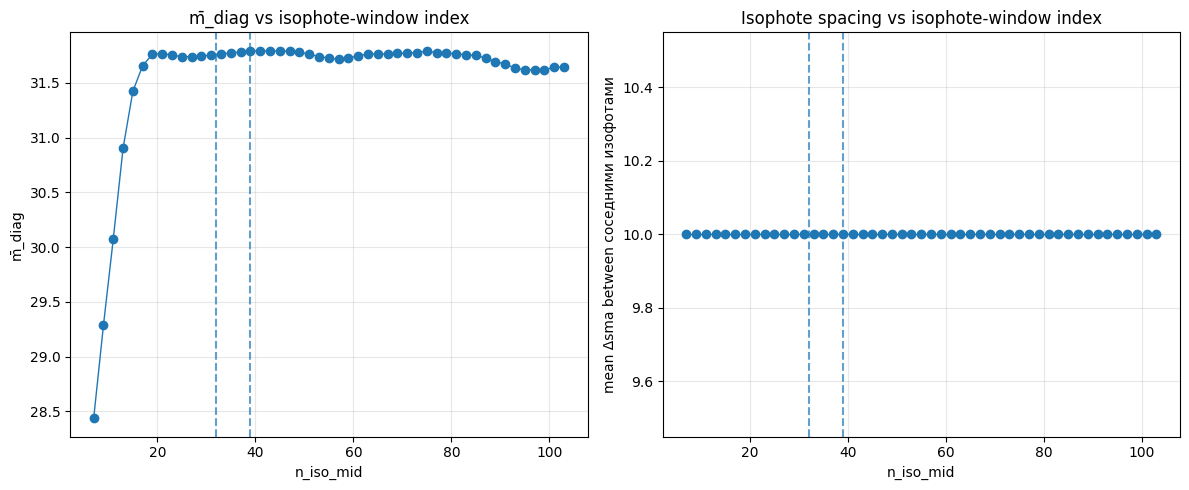

In [24]:

if not rows:
    raise RuntimeError("[PLOT-ISO] rows is empty")

# Сортируем по положению окна
rows_plot = sorted(rows, key=lambda r: r["i0"])

# X = середина окна в индексах fitted isophotes
n_iso_mid = np.array([r["i1"] for r in rows_plot], dtype=float)

# Y1 = диагностический mbar
mbar_diag = np.array([r["mbar"] for r in rows_plot], dtype=float)

# Y2 = средний зазор между соседними изофотами внутри окна
dsma_mean_arr = np.array([r["dsma_mean"] for r in rows_plot], dtype=float)

# Для наглядности отметим выбранное окно
#chosen_mid = 0.5 * (chosen["i0"] + chosen["i1"])

plt.figure(figsize=(12, 5))

# --- График 1: mbar vs n_iso_mid
plt.subplot(1, 2, 1)
plt.plot(n_iso_mid, mbar_diag, marker="o", linewidth=1)
plt.axvline(chosen["i0"], linestyle="--", alpha=0.7)
plt.axvline(chosen["i1"], linestyle="--", alpha=0.7)
plt.xlabel("n_iso_mid")
plt.ylabel("m̄_diag")
plt.title("m̄_diag vs isophote-window index")
plt.grid(True, alpha=0.3)

# --- График 2: dsma_mean vs n_iso_mid
plt.subplot(1, 2, 2)
plt.plot(n_iso_mid, dsma_mean_arr, marker="o", linewidth=1)
plt.axvline(chosen["i0"], linestyle="--", alpha=0.7)
plt.axvline(chosen["i1"], linestyle="--", alpha=0.7)
plt.xlabel("n_iso_mid")
plt.ylabel("mean Δsma between соседними изофотами")
plt.title("Isophote spacing vs isophote-window index")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

[19:59:44] plotting sigma-clipped residual-pixel distribution inside chosen SBF zone...
[19:59:44] [PLOT-HIST] raw N=115587, clipped N=115573, median=-5.280e-02, std=1.008e+00, dyn=1.313e+01


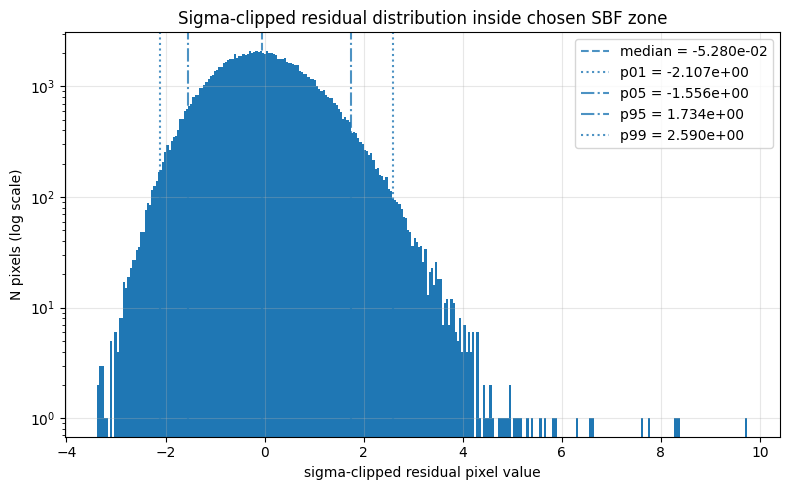

In [25]:
print("plotting sigma-clipped residual-pixel distribution inside chosen SBF zone...")

use_hist = (~mask_sbf) & np.isfinite(resid)
vals_hist = resid[use_hist]

if vals_hist.size < 5000:
    raise RuntimeError(f"[PLOT-HIST] too few residual pixels: N={vals_hist.size}")

# ------------------------------------------------------------
# 1. Sigma-clipping той же логикой, что и в выборе окон
# ------------------------------------------------------------
mean_clip, med_clip, std_clip = sigma_clipped_stats(
    vals_hist,
    sigma=CLIP_SIGMA_QC,
    maxiters=CLIP_MAXIT_QC
)

if (not np.isfinite(std_clip)) or std_clip <= 0:
    raise RuntimeError(f"[PLOT-HIST] bad clipped std={std_clip}")

lo_rob = med_clip - CLIP_SIGMA_QC * std_clip
hi_rob = med_clip + CLIP_SIGMA_QC * std_clip

vals_hist_rob = vals_hist[(vals_hist >= lo_rob) & (vals_hist <= hi_rob)]

if vals_hist_rob.size < 100:
    raise RuntimeError(f"[PLOT-HIST] too few sigma-clipped residual pixels: N={vals_hist_rob.size}")

# ------------------------------------------------------------
# 2. Статистики уже по clipped-распределению
# ------------------------------------------------------------
med_hist = float(np.nanmedian(vals_hist_rob))
p01 = float(np.nanpercentile(vals_hist_rob, 1.0))
p05 = float(np.nanpercentile(vals_hist_rob, 5.0))
p95 = float(np.nanpercentile(vals_hist_rob, 95.0))
p99 = float(np.nanpercentile(vals_hist_rob, 99.0))

dyn_hist = float(np.nanmax(vals_hist_rob) - np.nanmin(vals_hist_rob))
std_hist = float(np.nanstd(vals_hist_rob))

print(
    f"[PLOT-HIST] raw N={vals_hist.size}, clipped N={vals_hist_rob.size}, "
    f"median={med_hist:.3e}, std={std_hist:.3e}, dyn={dyn_hist:.3e}"
)

# ------------------------------------------------------------
# 3. Гистограмма clipped-распределения
# ------------------------------------------------------------
plt.figure(figsize=(8, 5))
plt.hist(vals_hist_rob, bins=300, log=True)

plt.axvline(med_hist, linestyle="--", alpha=0.8, label=f"median = {med_hist:.3e}")
plt.axvline(p01, linestyle=":", alpha=0.8, label=f"p01 = {p01:.3e}")
plt.axvline(p05, linestyle="-.", alpha=0.8, label=f"p05 = {p05:.3e}")
plt.axvline(p95, linestyle="-.", alpha=0.8, label=f"p95 = {p95:.3e}")
plt.axvline(p99, linestyle=":", alpha=0.8, label=f"p99 = {p99:.3e}")

plt.xlabel("sigma-clipped residual pixel value")
plt.ylabel("N pixels (log scale)")
plt.title("Sigma-clipped residual distribution inside chosen SBF zone")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Проверяем область + базовые статы

In [26]:
print("checking chosen SBF zone...")

use = (~mask_sbf) & np.isfinite(resid)
n_use = int(use.sum())

if n_use < 5000:
    raise RuntimeError(f"[SBF-ZONE] too few usable pixels: N={n_use}")

vals = resid[use]

# ------------------------------------------------------------
# 1. Сырые статистики
# ------------------------------------------------------------
vmin = float(np.nanmin(vals))
vmax = float(np.nanmax(vals))
vmed = float(np.nanmedian(vals))
vmean = float(np.nanmean(vals))
vstd = float(np.nanstd(vals))
vdyn = float(vmax - vmin)

p01 = float(np.nanpercentile(vals, 1.0))
p05 = float(np.nanpercentile(vals, 5.0))
p95 = float(np.nanpercentile(vals, 95.0))
p99 = float(np.nanpercentile(vals, 99.0))

print(
    f"[SBF-ZONE][raw] N={n_use}, "
    f"min={vmin:.3e}, p01={p01:.3e}, p05={p05:.3e}, \n"
    f"med={vmed:.3e}, mean={vmean:.3e}, std={vstd:.3e}, \n"
    f"p95={p95:.3e}, p99={p99:.3e}, max={vmax:.3e}, dyn={vdyn:.3e}"
)

# ------------------------------------------------------------
# 2. Sigma-clipped статистики
# ------------------------------------------------------------
mean_clip, med_clip, std_clip = sigma_clipped_stats(
    vals,
    sigma=CLIP_SIGMA_QC,
    maxiters=CLIP_MAXIT_QC
)

if (not np.isfinite(std_clip)) or std_clip <= 0:
    raise RuntimeError(f"[SBF-ZONE] bad clipped std={std_clip}")

lo_rob = med_clip - CLIP_SIGMA_QC * std_clip
hi_rob = med_clip + CLIP_SIGMA_QC * std_clip

vals_rob = vals[(vals >= lo_rob) & (vals <= hi_rob)]

if vals_rob.size < 100:
    raise RuntimeError(f"[SBF-ZONE] too few clipped pixels: N={vals_rob.size}")

vmin_rob = float(np.nanmin(vals_rob))
vmax_rob = float(np.nanmax(vals_rob))
vmed_rob = float(np.nanmedian(vals_rob))
vmean_rob = float(np.nanmean(vals_rob))
vstd_rob = float(np.nanstd(vals_rob))
vdyn_rob = float(vmax_rob - vmin_rob)

p01_rob = float(np.nanpercentile(vals_rob, 1.0))
p05_rob = float(np.nanpercentile(vals_rob, 5.0))
p95_rob = float(np.nanpercentile(vals_rob, 95.0))
p99_rob = float(np.nanpercentile(vals_rob, 99.0))

print(
    f"[SBF-ZONE][clipped] N={vals_rob.size}, "
    f"min={vmin_rob:.3e}, p01={p01_rob:.3e}, p05={p05_rob:.3e}, \n"
    f"med={vmed_rob:.3e}, mean={vmean_rob:.3e}, std={vstd_rob:.3e}, \n"
    f"p95={p95_rob:.3e}, p99={p99_rob:.3e}, max={vmax_rob:.3e}, dyn={vdyn_rob:.3e}"
)

[19:59:44] checking chosen SBF zone...
[19:59:44] [SBF-ZONE][raw] N=115587, min=-3.381e+00, p01=-2.107e+00, p05=-1.556e+00, 
med=-5.267e-02, mean=5.763e-03, std=1.035e+00, 
p95=1.736e+00, p99=2.599e+00, max=3.900e+01, dyn=4.238e+01
[19:59:44] [SBF-ZONE][clipped] N=115573, min=-3.381e+00, p01=-2.107e+00, p05=-1.556e+00, 
med=-5.280e-02, mean=3.415e-03, std=1.008e+00, 
p95=1.734e+00, p99=2.590e+00, max=9.747e+00, dyn=1.313e+01


## PSF (с кэшем)

Это лучше оставить отдельной ячейкой, потому что PSF — независимая боль.

In [27]:
print("loading/building PSF...")

psf_file = PSFREF if PSFREF is not None else f150w_path
psf_cache_path = out_dir / f"{stem}_psf_{PSF_SIZE}.fits"

if psf_cache_path.exists():
    with fits.open(psf_cache_path, memmap=False) as hd:
        psf = np.array(hd[0].data, dtype=float)
    psf = np.nan_to_num(psf, nan=0.0)
    psf /= psf.sum()
    print(f"[PSF] loaded cache → {psf_cache_path}")
else:
    sim = stpsf.setup_sim_to_match_file(psf_file)
    psf_hdul = sim.calc_psf(nlambda=PSF_NLAMBDA, fov_pixels=PSF_SIZE)

    if isinstance(psf_hdul, fits.HDUList):
        psf = np.array(psf_hdul[0].data, dtype=float)
    elif isinstance(psf_hdul, fits.PrimaryHDU):
        psf = np.array(psf_hdul.data, dtype=float)
    else:
        psf = np.array(psf_hdul, dtype=float)

    if psf.ndim == 3:
        psf = psf.sum(axis=0)

    psf = np.nan_to_num(psf, nan=0.0)
    psf /= psf.sum()

    fits.writeto(psf_cache_path, psf.astype(np.float32), overwrite=True)
    print(f"[PSF] saved cache → {psf_cache_path}")
print(f"[PSF] shape={psf.shape}, sum={psf.sum():.6f}, min={psf.min():.3e}, max={psf.max():.3e}")

[19:59:44] loading/building PSF...
[19:59:44] [PSF] loaded cache → ../data/NGC 1380/jw03055-o001_t001_nircam_clear-f150w_i2d_psf_129.fits
[19:59:44] [PSF] shape=(516, 516), sum=1.000000, min=6.482e-10, max=1.546e-02


##  FFT и P(k), E(k)

Это диагностика формы, не “истина по амплитуде”.

In [28]:
print(f"[FFT] workers={FFT_WORKERS}")

# ------------------------------------------------------------
# Параметры для эмпирического E(k)
# ------------------------------------------------------------
# N_E_REALIZATIONS:
#   сколько шумовых реализаций усреднять для expectation spectrum.
#   16 — разумный компромисс: уже не совсем шумно, но и не слишком долго.
N_E_REALIZATIONS = 16

# KBINS_N:
#   число радиальных бинов по k.
#   80 оставляем как раньше, чтобы сравнение было консистентным.
KBINS_N = 80

# ------------------------------------------------------------
# 1. Рабочее окно измерения
# ------------------------------------------------------------
window = (~mask_sbf) & np.isfinite(resid) & np.isfinite(model) & (model > 0.0)

n_use_fft = int(window.sum())
if n_use_fft < 5000:
    raise RuntimeError(f"[FFT] too few usable pixels for FFT: N={n_use_fft}")

W = window.astype(float)

# ------------------------------------------------------------
# 2. P(k) для реального residual
# ------------------------------------------------------------
data_fft = np.zeros_like(resid, dtype=float)
data_fft[window] = resid[window]

# Убираем среднее только в рабочей области
mean_fft = float(np.nanmean(data_fft[window]))
data_fft[window] -= mean_fft

print(f"[FFT] usable pixels={n_use_fft}, mean_removed={mean_fft:.3e}")

with set_workers(FFT_WORKERS):
    F = fft2(data_fft)

# Масштаб P2d пока оставляем простым:
# деление на число используемых пикселей.
P2d = (np.abs(F) ** 2) / float(n_use_fft)

# ------------------------------------------------------------
# 3. Общая k-сетка для 2D -> 1D
# ------------------------------------------------------------
ny, nx = resid.shape

ky = fftshift(fftfreq(ny))
kx = fftshift(fftfreq(nx))
KX, KY = np.meshgrid(kx, ky)
kr = np.hypot(KX, KY)

P2d_s = fftshift(P2d)

kbins = np.linspace(0.0, float(kr.max()), KBINS_N)

Pk_vals = np.full(len(kbins) - 1, np.nan, dtype=float)
Pk_k = np.full_like(Pk_vals, np.nan)

for i in range(len(Pk_vals)):
    sel = (kr >= kbins[i]) & (kr < kbins[i + 1])
    vals = P2d_s[sel]
    if vals.size > 10:
        Pk_vals[i] = float(np.nanmedian(vals))
        Pk_k[i] = 0.5 * (kbins[i] + kbins[i + 1])

mP = np.isfinite(Pk_vals) & np.isfinite(Pk_k) & (Pk_k > 0)
Pk = (Pk_k[mP], Pk_vals[mP])

print(f"[FFT] P(k) bins kept = {mP.sum()}")

# ------------------------------------------------------------
# 4. Подготовка большого PSF-ядра для свёртки шума
# ------------------------------------------------------------
big_psf = np.zeros((ny, nx), dtype=float)

py, px = psf.shape
y0_psf = ny // 2 - py // 2
x0_psf = nx // 2 - px // 2
big_psf[y0_psf:y0_psf + py, x0_psf:x0_psf + px] = psf

# ------------------------------------------------------------
# 5. Эмпирический E(k):
#    белый шум -> свёртка с PSF -> то же окно -> то же вычитание среднего -> FFT
# ------------------------------------------------------------
Ek_stack = []

rng = np.random.default_rng(None)

for i_real in range(N_E_REALIZATIONS):
    # Белый шум N(0,1) на полном кадре
    noise = rng.normal(loc=0.0, scale=1.0, size=(ny, nx))

    # Свёртка белого шума с PSF через FFT
    with set_workers(FFT_WORKERS):
        F_noise = fft2(noise)
        F_psf = fft2(big_psf)
        sim = np.real(np.fft.ifft2(F_noise * F_psf))

    # Применяем ТО ЖЕ окно, что и для данных
    sim_masked = np.zeros_like(sim, dtype=float)
    sim_masked[window] = sim[window]

    # Вычитаем среднее по той же рабочей области
    sim_mean = float(np.nanmean(sim_masked[window]))
    sim_masked[window] -= sim_mean

    # FFT симулированного поля
    with set_workers(FFT_WORKERS):
        F_sim = fft2(sim_masked)

    E2d_sim = (np.abs(F_sim) ** 2) / float(n_use_fft)
    E2d_sim_s = fftshift(E2d_sim)

    Ek_vals_i = np.full(len(kbins) - 1, np.nan, dtype=float)

    for j in range(len(Ek_vals_i)):
        sel = (kr >= kbins[j]) & (kr < kbins[j + 1])
        vals = E2d_sim_s[sel]
        if vals.size > 10:
            Ek_vals_i[j] = float(np.nanmedian(vals))

    Ek_stack.append(Ek_vals_i)

Ek_stack = np.array(Ek_stack, dtype=float)

# Усредняем expectation spectrum по реализациям
Ek_vals = np.nanmedian(Ek_stack, axis=0)
Ek_k = 0.5 * (kbins[:-1] + kbins[1:])

mE = np.isfinite(Ek_vals) & np.isfinite(Ek_k) & (Ek_k > 0)
Ek = (Ek_k[mE], Ek_vals[mE])

print(f"[FFT] E(k) bins kept = {mE.sum()}")
print(f"[FFT] E(k) realizations = {N_E_REALIZATIONS}")
print("[FFT] P(k) and empirical E(k) ready")

[19:59:44] [FFT] workers=-1
[19:59:45] [FFT] usable pixels=115587, mean_removed=5.763e-03
[19:59:53] [FFT] P(k) bins kept = 79
[20:02:52] [FFT] E(k) bins kept = 79
[20:02:52] [FFT] E(k) realizations = 16
[20:02:52] [FFT] P(k) and empirical E(k) ready


## Фит P0

In [29]:
print("fitting P(k) = P0 * E(k) + P1 ...")

# ------------------------------------------------------------------
# 1. Рабочее окно по пространственным частотам
# ------------------------------------------------------------------
# kmin=0.03:
#   отрезаем самые низкие частоты, где обычно сидят ошибки гладкой модели,
#   остаточные градиенты и оконная функция аннулуса.
#
# kmax=0.40:
#   отрезаем самые высокие частоты, где уже доминируют шум, дискретизация
#   и прочие мелкие гадости.
#
# Это пока эвристический диапазон, но для первой проверки он разумный.
kmin, kmax = 0.03, 0.40

kP, P = Pk
kE, E = Ek

sel = (kP >= kmin) & (kP <= kmax)

if int(sel.sum()) < 10:
    raise RuntimeError(f"[FIT] too few P(k) points in k-window: N={int(sel.sum())}")

# Интерполируем E(k) на сетку P(k), чтобы сравнивать одно с другим по одним и тем же k.
E_int = np.interp(kP[sel], kE, E, left=np.nan, right=np.nan)

x = E_int
y = P[sel]

# Оставляем только конечные и положительные значения.
# P(k) и E(k) физически должны быть > 0.
m = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)
x = x[m]
y = y[m]

if x.size < 10:
    raise RuntimeError(f"[FIT] too few valid points after cleaning: N={x.size}")

# ------------------------------------------------------------------
# 2. Диагностика: насколько форма P(k) вообще похожа на E(k)
# ------------------------------------------------------------------
corr = float(np.corrcoef(x, y)[0, 1])
print(f"[FIT] window k={kmin:.3f}..{kmax:.3f}, N={x.size}, corr(E,P)≈{corr:.3f}")

# Если корреляция совсем слабая, P0 интерпретировать будет опасно.
# Но пока не падаем, а просто честно печатаем предупреждение.
if not np.isfinite(corr) or abs(corr) < 0.3:
    print("[FIT] WARNING: weak correlation between E(k) and P(k)")

# ------------------------------------------------------------------
# 3. Линейный фит y = P0 * x + P1
# ------------------------------------------------------------------
A = np.vstack([x, np.ones_like(x)]).T
P0, P1 = np.linalg.lstsq(A, y, rcond=None)[0]

# frac = какая доля модели приходится на PSF-подобную компоненту
den = P0 + P1
frac = float(P0 / den) if np.isfinite(den) and den != 0 else np.nan

print(f"[FIT] P0={P0:.3e}, P1={P1:.3e}, frac={frac:.3f}")
print(
    f"[FIT] x-range=[{np.nanmin(x):.3e}, {np.nanmax(x):.3e}], "
    f"y-range=[{np.nanmin(y):.3e}, {np.nanmax(y):.3e}]"
)
y_fit = P0 * x + P1
fit_resid = y - y_fit
print(
    f"[FIT] residuals: med={np.nanmedian(fit_resid):.3e}, "
    f"std={np.nanstd(fit_resid):.3e}"
)
# ------------------------------------------------------------------
# 4. Доп. sanity-check
# ------------------------------------------------------------------
if not np.isfinite(P0) or not np.isfinite(P1):
    print("[FIT] WARNING: non-finite fit coefficients")

if P0 <= 0:
    print("[FIT] WARNING: P0 <= 0, physical SBF interpretation is doubtful")

if np.isfinite(P1) and abs(P1) > 5.0 * max(P0, 1e-30):
    print("[FIT] WARNING: |P1| >> P0, white-noise term dominates fit")

[20:02:52] fitting P(k) = P0 * E(k) + P1 ...
[20:02:52] [FIT] window k=0.030..0.400, N=42, corr(E,P)≈0.875
[20:02:52] [FIT] P0=4.832e+01, P1=1.552e+00, frac=0.969
[20:02:52] [FIT] x-range=[3.133e-05, 2.364e-01], y-range=[9.180e-02, 9.946e+00]
[20:02:52] [FIT] residuals: med=-3.868e-01, std=1.399e+00


## Базовый расчёт m̄

Это твой текущий способ через var_sbf / Imean.

In [ ]:
print("computing mbar from spectral P0 ...")

# ------------------------------------------------------------
# 1. Средняя яркость галактики в том же эллиптическом аннулусе
# ------------------------------------------------------------
# Берём только те пиксели модели, которые реально участвуют в SBF-анализе.
window_main = (~mask_sbf) & np.isfinite(resid) & np.isfinite(model) & (model > 0.0)
if "window" not in globals() or not np.array_equal(window, window_main):
    raise RuntimeError("[SBF] window does not match current mask_sbf/resid/model; rerun FFT and fit cells before mbar")

use_I = window_main

n_I = int(use_I.sum())
if n_I < 5000:
    raise RuntimeError(f"[SBF] too few model pixels in annulus: N={n_I}")

Imean = float(np.nanmean(model[use_I]))
print(
    f"[SBF] model in zone: N={n_I}, "
    f"min={np.nanmin(model[use_I]):.3e}, "
    f"med={np.nanmedian(model[use_I]):.3e}, "
    f"max={np.nanmax(model[use_I]):.3e}"
)
if (not np.isfinite(Imean)) or (Imean <= 0.0):
    raise RuntimeError(f"[SBF] bad Imean={Imean}")

# ------------------------------------------------------------
# 2. Основная SBF-амплитуда из спектрального fit-а
# ------------------------------------------------------------
# Здесь мы считаем P0 главным результатом.
# Логика такая:
# - P(k) у тебя посчитан на residual в рабочем аннулусе,
# - E(k) посчитан в ТОЙ ЖЕ вычислительной схеме,
# - значит fitted P0 — это лучшая оценка амплитуды SBF-компоненты
#   в power-spectrum смысле.
if (not np.isfinite(P0)) or (P0 <= 0.0):
    raise RuntimeError(f"[SBF] bad spectral P0={P0}")

# ------------------------------------------------------------
# 2a. Диагностическая formal uncertainty для текущего spectral fit
# ------------------------------------------------------------
# Это только ошибка линейного fit-а при фиксированных mask, PSF, kmin/kmax и residual.
# Она не включает scatter между annuli, неопределённость PSF/background/model и pipeline systematic.
n_fit_main = 0
fit_resid_std_main = np.nan
P0_fit_sigma_main = np.nan
P1_fit_sigma_main = np.nan
mbar_fit_sigma_main = np.nan
fit_uncertainty_note = "fit covariance unavailable"

if "x" in globals() and "y" in globals():
    x_fit = np.asarray(x, dtype=float)
    y_fit_data = np.asarray(y, dtype=float)
    good_fit = np.isfinite(x_fit) & np.isfinite(y_fit_data)
    x_fit = x_fit[good_fit]
    y_fit_data = y_fit_data[good_fit]

    if x_fit.size >= 3:
        A_fit = np.vstack([x_fit, np.ones_like(x_fit)]).T
        fit_resid_main = y_fit_data - (P0 * x_fit + P1)
        n_fit_main = int(x_fit.size)
        dof_fit = max(n_fit_main - 2, 1)
        fit_resid_std_main = float(np.nanstd(fit_resid_main, ddof=1))

        try:
            sigma2_fit = float(np.nansum(fit_resid_main * fit_resid_main) / dof_fit)
            cov_fit = sigma2_fit * np.linalg.pinv(A_fit.T @ A_fit)
            P0_fit_sigma_main = float(np.sqrt(max(cov_fit[0, 0], 0.0)))
            P1_fit_sigma_main = float(np.sqrt(max(cov_fit[1, 1], 0.0)))
            if np.isfinite(P0_fit_sigma_main) and P0_fit_sigma_main > 0.0:
                mbar_fit_sigma_main = float((2.5 / np.log(10.0)) * P0_fit_sigma_main / P0)
                fit_uncertainty_note = "formal covariance of P(k)=P0*E(k)+P1"
        except Exception as err:
            fit_uncertainty_note = f"fit covariance failed: {err}"
    else:
        fit_uncertainty_note = f"too few fit points: N={x_fit.size}"
else:
    fit_uncertainty_note = "x/y from the fit cell are unavailable"

Pf_spec = float(P0 / Imean)
Pf_spec_sigma_formal = np.nan
if np.isfinite(P0_fit_sigma_main) and P0_fit_sigma_main > 0.0:
    Pf_spec_sigma_formal = float(Pf_spec * P0_fit_sigma_main / P0)


if (not np.isfinite(Pf_spec)) or (Pf_spec <= 0.0):
    raise RuntimeError(f"[SBF] bad Pf_spec={Pf_spec}")

# ------------------------------------------------------------
# 3. AB zero point для величины в MJy/sr на пиксель
# ------------------------------------------------------------
# 2.350443e-5:
#   перевод из MJy/sr в Jy/arcsec^2.
# pix_area:
#   площадь пикселя в arcsec^2.
jy_per_pix = 2.350443e-5 * pix_area

# 3631 Jy:
#   определение нулевой точки AB-системы.
zp_ab = float(-2.5 * np.log10(jy_per_pix / 3631.0))

# ------------------------------------------------------------
# 4. Итоговая SBF-величина
# ------------------------------------------------------------
mbar_spec = float(-2.5 * np.log10(Pf_spec) + zp_ab)
print(f"[SBF] zp_ab={zp_ab:.6f}")
print(f"[SBF] Imean={Imean:.3e}")
print(f"[SBF] P0={P0:.3e}, P1={P1:.3e}, frac={frac:.3f}")
print(f"[SBF] Pf_spec={Pf_spec:.3e}")
print(f"m̄(F150W) [spectral] = {mbar_spec:.3f} mag")

print(
    f"[SBF-UNC][formal-fit] N_fit={n_fit_main}, "
    f"fit_resid_std={fit_resid_std_main:.3e} power-units"
)
if np.isfinite(P0_fit_sigma_main) and P0_fit_sigma_main > 0.0:
    print(
        f"[SBF-UNC][formal-fit] sigma(P0)={P0_fit_sigma_main:.3e} "
        f"({P0_fit_sigma_main / P0:.3%}), sigma(Pf)={Pf_spec_sigma_formal:.3e}"
    )
    print(f"[SBF-UNC][formal-fit] sigma(mbar)={mbar_fit_sigma_main:.4f} mag")
else:
    print(f"[SBF-UNC][formal-fit] unavailable: {fit_uncertainty_note}")
print("[SBF-UNC] formal-fit sigma is diagnostic only; adopted uncertainty is computed later from annuli/pipeline terms")

sbf_main_diagnostics = {
    "region": "elliptical_chosen",
    "kmin": float(kmin),
    "kmax": float(kmax),
    "n_use": int(globals().get("n_use_fft", n_I)),
    "n_fit": int(n_fit_main),
    "Imean": Imean,
    "P0": float(P0),
    "P1": float(P1),
    "Pf_spec": Pf_spec,
    "mbar_spec": mbar_spec,
    "fit_resid_std": fit_resid_std_main,
    "P0_fit_sigma": P0_fit_sigma_main,
    "P1_fit_sigma": P1_fit_sigma_main,
    "Pf_spec_sigma_formal": Pf_spec_sigma_formal,
    "mbar_fit_sigma": mbar_fit_sigma_main,
    "notes": fit_uncertainty_note,
}
display(pd.DataFrame([sbf_main_diagnostics]))

[20:52:32] computing mbar from spectral P0 ...
[20:52:33] [SBF] model in zone: N=115587, min=1.791e+01, med=2.026e+01, max=2.369e+01
[20:52:33] [SBF] zp_ab=27.999575
[20:52:33] [SBF] Imean=2.044e+01
[20:52:33] [SBF] P0=4.832e+01, P1=1.552e+00, frac=0.969
[20:52:33] [SBF] Pf_spec=2.364e+00
[20:52:33] m̄(F150W) [spectral] = 27.065 mag
[20:52:33] [SBF-UNC][formal-fit] N_fit=42, fit_resid_std=1.416e+00 power-units
[20:52:33] [SBF-UNC][formal-fit] sigma(P0)=4.219e+00 (8.733%), sigma(Pf)=2.065e-01
[20:52:33] [SBF-UNC][formal-fit] sigma(mbar)=0.0948 mag
[20:52:33] [SBF-UNC] formal-fit sigma is diagnostic only; adopted uncertainty is computed later from annuli/pipeline terms


,region,kmin,kmax,n_use,n_fit,Imean,P0,P1,Pf_spec,mbar_spec,fit_resid_std,P0_fit_sigma,P1_fit_sigma,Pf_spec_sigma_formal,mbar_fit_sigma,notes
0,elliptical_chosen,0.04,0.35,115587,42,20.43521,48.315491,1.551806,2.364326,27.065306,1.416115,4.219279,0.242675,0.206471,0.094815,formal covariance of P(k)=P0*E(k)+P1


## spectral mbar across plateau windows

In [31]:
print("measuring spectral mbar across plateau windows...")

if best_plateau is None:
    subset = [chosen]
else:
    subset = rows_sorted[best_plateau["i0"]:best_plateau["i1"] + 1]

spec_rows = []
for j, row in enumerate(subset):
    print(
        f"[SBF-SPEC-PLATEAU] window {j+1}/{len(subset)}: "
        f"sma={row['sma_in']:.1f}..{row['sma_out']:.1f}"
    )

    out = measure_sbf_spec_for_row(
        row=row,
        resid=resid,
        model=model,
        premask=premask,
        psf=psf,
        pix_area=pix_area,
        kmin=0.03,
        kmax=0.40,
        fft_workers=FFT_WORKERS,
        n_e_realizations=8,
        kbins_n=80,
    )


    if out is not None:
        print(
            f"[SBF-SPEC-PLATEAU]   -> "
            f"m̄_spec={out['mbar_spec']:.4f}, "
            f"P0={out['P0']:.3e}, "
            f"Imean={out['Imean']:.3e}, "
            f"Pf={out['Pf_spec']:.3e}, "
            f"corr={out['corr']:.3f}, "
            f"frac={out['frac']:.3f}, "
            f"N={out['n_use']}"
        )
        spec_rows.append(out)
    else:
        print("[SBF-SPEC-PLATEAU]   -> failed")

min_success = 1 if best_plateau is None else 3
if len(spec_rows) < min_success:
    raise RuntimeError(
        f"[SBF-SPEC-PLATEAU] too few successful spectral windows: N={len(spec_rows)}"
    )

mbar_spec_arr = np.array([r["mbar_spec"] for r in spec_rows], dtype=float)
P0_arr = np.array([r["P0"] for r in spec_rows], dtype=float)
corr_arr = np.array([r["corr"] for r in spec_rows], dtype=float)

mbar_spec_med = float(np.nanmedian(mbar_spec_arr))
mbar_spec_std = float(np.nanstd(mbar_spec_arr))

mbar_spec_mad = float(np.nanmedian(np.abs(mbar_spec_arr - mbar_spec_med)))
sigma_zone_spec = 1.4826 * mbar_spec_mad

print(f"[SBF-SPEC-PLATEAU] successful windows = {len(spec_rows)}")
print(f"[SBF-SPEC-PLATEAU] mbar_spec median = {mbar_spec_med:.4f} mag")
print(f"[SBF-SPEC-PLATEAU] mbar_spec std    = {mbar_spec_std:.4e} mag")
print(f"[SBF-SPEC-PLATEAU] sigma_zone_spec  = {sigma_zone_spec:.4e} mag")
print(f"[SBF-SPEC-PLATEAU] P0 median        = {np.nanmedian(P0_arr):.4e}")
print(f"[SBF-SPEC-PLATEAU] corr median      = {np.nanmedian(corr_arr):.4f}")

[20:02:52] measuring spectral mbar across plateau windows...
[20:02:52] [SBF-SPEC-PLATEAU] window 1/5: sma=340.0..410.0
[20:04:26] [SBF-SPEC-PLATEAU]   -> m̄_spec=27.0770, P0=4.780e+01, Imean=2.044e+01, Pf=2.339e+00, corr=0.874, frac=0.968, N=115587
[20:04:26] [SBF-SPEC-PLATEAU] window 2/5: sma=360.0..430.0
[20:05:52] [SBF-SPEC-PLATEAU]   -> m̄_spec=26.5017, P0=7.579e+01, Imean=1.908e+01, Pf=3.973e+00, corr=0.909, frac=0.974, N=120937
[20:05:52] [SBF-SPEC-PLATEAU] window 3/5: sma=380.0..450.0
[20:07:21] [SBF-SPEC-PLATEAU]   -> m̄_spec=26.5276, P0=6.923e+01, Imean=1.784e+01, Pf=3.880e+00, corr=0.907, frac=0.974, N=126665
[20:07:21] [SBF-SPEC-PLATEAU] window 4/5: sma=400.0..470.0
[20:08:46] [SBF-SPEC-PLATEAU]   -> m̄_spec=26.5000, P0=6.741e+01, Imean=1.694e+01, Pf=3.979e+00, corr=0.908, frac=0.974, N=130101
[20:08:46] [SBF-SPEC-PLATEAU] window 5/5: sma=420.0..490.0
[20:10:20] [SBF-SPEC-PLATEAU]   -> m̄_spec=26.3512, P0=7.271e+01, Imean=1.593e+01, Pf=4.564e+00, corr=0.914, frac=0.976, N=1

## Цвет по F090W/F150W

Грубая диагностика, как и у тебя было.

In [32]:
print("computing color in the same chosen SBF zone...")

if img_f090 is not None:
    ny_c = min(img.shape[0], img_f090.shape[0])
    nx_c = min(img.shape[1], img_f090.shape[1])

    img150_c = img[:ny_c, :nx_c]
    img090_c = img_f090[:ny_c, :nx_c]

    valid150_c = valid150[:ny_c, :nx_c]
    valid090_c = valid090[:ny_c, :nx_c]
    mask_sbf_c = mask_sbf[:ny_c, :nx_c]

    use_color = (
        (~mask_sbf_c) &
        valid150_c & valid090_c &
        np.isfinite(img150_c) & np.isfinite(img090_c)
    )

    n_color = int(use_color.sum())
    if n_color <= 100:
        print(f"[COLOR] too few usable pixels: N={n_color}")
    else:
        vals150 = img150_c[use_color]
        vals090 = img090_c[use_color]

        # Робастно режем хвосты отдельно в каждом фильтре
        _, med150_clip, std150_clip = sigma_clipped_stats(
            vals150, sigma=3.0, maxiters=5
        )
        _, med090_clip, std090_clip = sigma_clipped_stats(
            vals090, sigma=3.0, maxiters=5
        )

        lo150 = med150_clip - 3.0 * std150_clip
        hi150 = med150_clip + 3.0 * std150_clip
        lo090 = med090_clip - 3.0 * std090_clip
        hi090 = med090_clip + 3.0 * std090_clip

        keep = (
            (vals150 >= lo150) & (vals150 <= hi150) &
            (vals090 >= lo090) & (vals090 <= hi090)
        )

        vals150_rob = vals150[keep]
        vals090_rob = vals090[keep]

        n_rob = int(vals150_rob.size)
        if n_rob <= 100:
            print(f"[COLOR] too few sigma-clipped pixels: N={n_rob}")
        else:
            f150_med = float(np.nanmedian(vals150_rob))
            f090_med = float(np.nanmedian(vals090_rob))

            if f150_med > 0 and f090_med > 0:
                color = float(-2.5 * np.log10(f090_med / f150_med))
                print(
                    f"[COLOR] N_raw={n_color}, N_clip={n_rob}, "
                    f"F150_med={f150_med:.3e}, F090_med={f090_med:.3e}, "
                    f"(F090W - F150W) ≈ {color:.3f} mag"
                )
            else:
                print("[COLOR] median brightness not positive, color skipped")

[20:10:20] computing color in the same chosen SBF zone...
[20:10:22] [COLOR] N_raw=115587, N_clip=115346, F150_med=2.032e+01, F090_med=1.276e+01, (F090W - F150W) ≈ 0.505 mag


## circles scan

In [33]:
def build_region_mask_ellipse(shape, x0, y0, q, pa, sma_in, sma_out):
    ny, nx = shape
    yy, xx = np.indices((ny, nx), dtype=float)

    dx = xx - x0
    dy = yy - y0

    cosp = np.cos(pa)
    sinp = np.sin(pa)

    xp = dx * cosp + dy * sinp
    yp = -dx * sinp + dy * cosp

    r_ell = np.sqrt(xp * xp + (yp / q) * (yp / q))
    return (r_ell >= sma_in) & (r_ell <= sma_out)


def build_region_mask_circle(shape, x0, y0, r_in, r_out):
    ny, nx = shape
    yy, xx = np.indices((ny, nx), dtype=float)
    rr = np.hypot(xx - x0, yy - y0)
    return (rr >= r_in) & (rr <= r_out)

In [34]:
def measure_sbf_for_mask(
    region_mask,
    resid,
    model,
    premask,
    psf,
    pix_area,
    kmin,
    kmax,
    fft_workers=-1,
    n_e_realizations=16,
    kbins_n=80,
):
    mask_sbf_local = premask | (~region_mask)
    window = (~mask_sbf_local) & np.isfinite(resid) & np.isfinite(model) & (model > 0.0)

    n_use = int(window.sum())
    if n_use < 5000:
        return None

    use_I = window
    n_I = int(use_I.sum())
    if n_I < 5000:
        return None

    Imean = float(np.nanmean(model[use_I]))
    if (not np.isfinite(Imean)) or (Imean <= 0):
        return None

    data_fft = np.zeros_like(resid, dtype=float)
    data_fft[window] = resid[window]
    data_fft[window] -= float(np.nanmean(data_fft[window]))

    with set_workers(fft_workers):
        F = fft2(data_fft)

    P2d = (np.abs(F) ** 2) / float(n_use)

    ny, nx = resid.shape
    ky = fftshift(fftfreq(ny))
    kx = fftshift(fftfreq(nx))
    KX, KY = np.meshgrid(kx, ky)
    kr = np.hypot(KX, KY)

    P2d_s = fftshift(P2d)
    kbins = np.linspace(0.0, float(kr.max()), kbins_n)

    Pk_vals = np.full(len(kbins) - 1, np.nan, dtype=float)
    Pk_k = np.full_like(Pk_vals, np.nan)

    for i in range(len(Pk_vals)):
        sel = (kr >= kbins[i]) & (kr < kbins[i + 1])
        vals = P2d_s[sel]
        if vals.size > 10:
            Pk_vals[i] = float(np.nanmedian(vals))
            Pk_k[i] = 0.5 * (kbins[i] + kbins[i + 1])

    mP = np.isfinite(Pk_vals) & np.isfinite(Pk_k) & (Pk_k > 0)
    if int(mP.sum()) < 10:
        return None

    kP = Pk_k[mP]
    P = Pk_vals[mP]

    big_psf = np.zeros((ny, nx), dtype=float)
    py, px = psf.shape
    y0_psf = ny // 2 - py // 2
    x0_psf = nx // 2 - px // 2
    big_psf[y0_psf:y0_psf + py, x0_psf:x0_psf + px] = psf

    with set_workers(fft_workers):
        F_psf = fft2(big_psf)

    rng = np.random.default_rng(None)
    Ek_stack = []

    for _ in range(n_e_realizations):
        noise = rng.normal(0.0, 1.0, size=(ny, nx))

        with set_workers(fft_workers):
            F_noise = fft2(noise)
            sim = np.real(np.fft.ifft2(F_noise * F_psf))

        sim_masked = np.zeros_like(sim, dtype=float)
        sim_masked[window] = sim[window]
        sim_masked[window] -= float(np.nanmean(sim_masked[window]))

        with set_workers(fft_workers):
            F_sim = fft2(sim_masked)

        E2d_sim = (np.abs(F_sim) ** 2) / float(n_use)
        E2d_sim_s = fftshift(E2d_sim)

        Ek_vals_i = np.full(len(kbins) - 1, np.nan, dtype=float)
        for j in range(len(Ek_vals_i)):
            sel = (kr >= kbins[j]) & (kr < kbins[j + 1])
            vals = E2d_sim_s[sel]
            if vals.size > 10:
                Ek_vals_i[j] = float(np.nanmedian(vals))
        Ek_stack.append(Ek_vals_i)

    Ek_stack = np.array(Ek_stack, dtype=float)
    Ek_vals = np.nanmedian(Ek_stack, axis=0)
    Ek_k = 0.5 * (kbins[:-1] + kbins[1:])

    mE = np.isfinite(Ek_vals) & np.isfinite(Ek_k) & (Ek_k > 0)
    if int(mE.sum()) < 10:
        return None

    kE = Ek_k[mE]
    E = Ek_vals[mE]

    sel = (kP >= kmin) & (kP <= kmax)
    if int(sel.sum()) < 10:
        return None

    E_int = np.interp(kP[sel], kE, E, left=np.nan, right=np.nan)
    x = E_int
    y = P[sel]

    good = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)
    x = x[good]
    y = y[good]
    if x.size < 10:
        return None

    corr = float(np.corrcoef(x, y)[0, 1])

    A = np.vstack([x, np.ones_like(x)]).T
    P0, P1 = np.linalg.lstsq(A, y, rcond=None)[0]
    if (not np.isfinite(P0)) or (P0 <= 0):
        return None

    y_fit = P0 * x + P1
    fit_resid = y - y_fit
    fit_resid_std = float(np.nanstd(fit_resid, ddof=1)) if x.size > 2 else float(np.nanstd(fit_resid))

    # fit_resid_std is a power-spectrum residual, not directly an error in mag.
    # Convert the fixed-window linear-fit covariance of P0 into a formal mbar error proxy.
    P0_fit_sigma = np.nan
    mbar_fit_sigma = np.nan
    dof = max(int(x.size) - 2, 1)
    try:
        sigma2_fit = float(np.nansum(fit_resid * fit_resid) / dof)
        cov_fit = sigma2_fit * np.linalg.pinv(A.T @ A)
        P0_fit_sigma = float(np.sqrt(max(cov_fit[0, 0], 0.0)))
        if np.isfinite(P0_fit_sigma) and P0_fit_sigma > 0.0:
            mbar_fit_sigma = float((2.5 / np.log(10.0)) * P0_fit_sigma / P0)
    except Exception:
        pass

    Pf_spec = float(P0 / Imean)
    if (not np.isfinite(Pf_spec)) or (Pf_spec <= 0):
        return None

    jy_per_pix = 2.350443e-5 * pix_area
    zp_ab = float(-2.5 * np.log10(jy_per_pix / 3631.0))
    mbar_spec = float(-2.5 * np.log10(Pf_spec) + zp_ab)

    den = P0 + P1
    frac = float(P0 / den) if np.isfinite(den) and den != 0 else np.nan

    return {
        "n_use": n_use,
        "Imean": Imean,
        "P0": float(P0),
        "P1": float(P1),
        "frac": frac,
        "corr": corr,
        "n_fit": int(x.size),
        "fit_resid_std": fit_resid_std,
        "P0_fit_sigma": P0_fit_sigma,
        "mbar_fit_sigma": mbar_fit_sigma,
        "Pf_spec": Pf_spec,
        "mbar_spec": mbar_spec,
    }

In [ ]:

pix_scale = float(np.sqrt(pix_area))   # arcsec/pix

r1_in, r1_out = 8.2 / pix_scale, 16.4 / pix_scale
r2_in, r2_out = 16.4 / pix_scale, 32.8 / pix_scale

regions = [
    {
        "region": "elliptical_chosen",
        "shape": "ellipse",
        "mask": build_region_mask_ellipse(
            resid.shape, x0_ann, y0_ann, q_ann, pa_ann, sma_in, sma_out
        ),
        "rin_px": sma_in,
        "rout_px": sma_out,
    },
    {
        "region": "circular_inner_lit",
        "shape": "circle",
        "mask": build_region_mask_circle(
            resid.shape, x0_ann, y0_ann, r1_in, r1_out
        ),
        "rin_px": r1_in,
        "rout_px": r1_out,
    },
    {
        "region": "circular_outer_lit",
        "shape": "circle",
        "mask": build_region_mask_circle(
            resid.shape, x0_ann, y0_ann, r2_in, r2_out
        ),
        "rin_px": r2_in,
        "rout_px": r2_out,
    },
]

k_windows = [
    (0.02, 0.35),
    (0.03, 0.40),
    (0.04, 0.35),
]

rows_df = []

for reg in regions:
    for kmin, kmax in k_windows:
        out = measure_sbf_for_mask(
            region_mask=reg["mask"],
            resid=resid,
            model=model,
            premask=premask,
            psf=psf,
            pix_area=pix_area,
            kmin=kmin,
            kmax=kmax,
            fft_workers=FFT_WORKERS,
            n_e_realizations=8,
            kbins_n=80,
        )

        if out is None:
            rows_df.append({
                "region": reg["region"],
                "shape": reg["shape"],
                "rin_px": reg["rin_px"],
                "rout_px": reg["rout_px"],
                "kmin": kmin,
                "kmax": kmax,
                "status": "failed",
            })
        else:
            rows_df.append({
                "region": reg["region"],
                "shape": reg["shape"],
                "rin_px": reg["rin_px"],
                "rout_px": reg["rout_px"],
                "kmin": kmin,
                "kmax": kmax,
                "status": "ok",
                **out,
            })


In [ ]:

df_sbf = pd.DataFrame(rows_df)
display(df_sbf)

,region,shape,rin_px,rout_px,kmin,kmax,status,n_use,Imean,P0,P1,frac,corr,fit_resid_std,Pf_spec,mbar_spec
0,elliptical_chosen,ellipse,340.000000,410.000000,0.02,0.35,ok,115587,20.435210,41.845018,1.908256,0.956386,0.900573,1.402977,2.047692,27.221413
1,elliptical_chosen,ellipse,340.000000,410.000000,0.03,0.40,ok,115587,20.435210,46.162925,1.569046,0.967128,0.870659,1.423516,2.258990,27.114789
2,elliptical_chosen,ellipse,340.000000,410.000000,0.04,0.35,ok,115587,20.435210,54.173571,1.736805,0.968936,0.886885,1.255442,2.650992,26.941054
3,circular_inner_lit,circle,262.597443,525.194886,0.02,0.35,ok,649910,14.627394,43.979355,1.792640,0.960835,0.920217,1.412749,3.006643,26.804370
4,circular_inner_lit,circle,262.597443,525.194886,0.03,0.40,ok,649910,14.627394,53.810011,1.388954,0.974837,0.915656,1.278451,3.678715,26.585334
5,circular_inner_lit,circle,262.597443,525.194886,0.04,0.35,ok,649910,14.627394,57.662812,1.585365,0.973242,0.908364,1.210388,3.942111,26.510252
6,circular_outer_lit,circle,525.194886,1050.389772,0.02,0.35,ok,1187302,6.987641,103.416083,1.677560,0.984037,0.985136,1.317485,14.799857,25.073931
7,circular_outer_lit,circle,525.194886,1050.389772,0.03,0.40,ok,1187302,6.987641,105.801528,1.391315,0.987020,0.973576,1.348991,15.141237,25.049171
8,circular_outer_lit,circle,525.194886,1050.389772,0.04,0.35,ok,1187302,6.987641,108.298227,1.604743,0.985399,0.966039,1.315271,15.498539,25.023848


## Weighted SBF result from circular annuli

Эта ячейка не меняет измерения `df_sbf`; она только объединяет два опубликованных круговых annuli и явно разделяет formal measurement error, scatter между annuli и будущую pipeline systematic.

In [ ]:
print("combining circular SBF annuli with weighted mean...")

required_annuli = ["circular_inner_lit", "circular_outer_lit"]
df_sbf_ok = df_sbf[df_sbf["status"].eq("ok")].copy()


def _finite_positive(value):
    try:
        value = float(value)
    except (TypeError, ValueError):
        return False
    return np.isfinite(value) and value > 0.0


def _robust_mag_scatter(values):
    """Robust scatter in mag for repeated k-window measurements of the same annulus."""
    arr = np.asarray(values, dtype=float)
    arr = arr[np.isfinite(arr)]

    if arr.size >= 3:
        med = float(np.nanmedian(arr))
        mad_sigma = float(1.4826 * np.nanmedian(np.abs(arr - med)))
        std_sigma = float(np.nanstd(arr, ddof=1))
        if _finite_positive(mad_sigma):
            return mad_sigma, "k-window MAD"
        if _finite_positive(std_sigma):
            return std_sigma, "k-window std"

    if arr.size >= 2:
        std_sigma = float(np.nanstd(arr, ddof=1))
        half_range = float(0.5 * (np.nanmax(arr) - np.nanmin(arr)))
        if _finite_positive(std_sigma):
            return std_sigma, "k-window std"
        if _finite_positive(half_range):
            return half_range, "k-window half-range"

    return np.nan, "no k-window scatter"


# sigma_meas for one annulus:
# 1. Prefer scatter over repeated k-windows for the same annulus. This is analogous in spirit
#    to plateau-window scatter, but for the circular annuli in df_sbf.
# 2. Use the regression-derived mbar_fit_sigma as a lower-level formal fit diagnostic when present.
# 3. Only as a last resort, use a clearly labelled fit_resid_std/P0 proxy. fit_resid_std itself
#    is not treated as a magnitude uncertainty.
region_sigma_info = {}
for region_name, grp in df_sbf_ok.groupby("region"):
    sigma_k, sigma_method = _robust_mag_scatter(grp["mbar_spec"].values)
    region_sigma_info[region_name] = {
        "sigma_kwindow": sigma_k,
        "sigma_method": sigma_method,
    }


def _fit_resid_proxy_mag(row):
    fit_resid_std = row.get("fit_resid_std", np.nan)
    P0_row = row.get("P0", np.nan)
    if _finite_positive(fit_resid_std) and _finite_positive(abs(P0_row)):
        return float((2.5 / np.log(10.0)) * fit_resid_std / abs(P0_row))
    return np.nan


def _measurement_sigma_for_row(row):
    candidates = []
    info = region_sigma_info.get(row["region"], {})

    sigma_k = info.get("sigma_kwindow", np.nan)
    if _finite_positive(sigma_k):
        candidates.append((float(sigma_k), info.get("sigma_method", "k-window scatter")))

    sigma_fit = row.get("mbar_fit_sigma", np.nan)
    if _finite_positive(sigma_fit):
        candidates.append((float(sigma_fit), "fit covariance"))

    if candidates:
        # Conservative fixed-window sigma_meas: do not let a tiny formal fit covariance
        # dominate over the observed sensitivity to the chosen k-window.
        sigma, method = max(candidates, key=lambda item: item[0])
        if len(candidates) > 1:
            method = "max(" + ", ".join(m for _, m in candidates) + ")"
        return sigma, method

    sigma_proxy = _fit_resid_proxy_mag(row)
    if _finite_positive(sigma_proxy):
        return sigma_proxy, "fit_resid_std/P0 proxy"

    return np.nan, "sigma unavailable"


def _row_for(region_name, kmin_value, kmax_value):
    if df_sbf_ok.empty:
        return None
    match = df_sbf_ok[
        df_sbf_ok["region"].eq(region_name)
        & np.isclose(df_sbf_ok["kmin"].astype(float), float(kmin_value))
        & np.isclose(df_sbf_ok["kmax"].astype(float), float(kmax_value))
    ]
    if match.empty:
        return None
    return match.iloc[0]


def _annulus_measurement(region_name, kmin_value, kmax_value):
    row = _row_for(region_name, kmin_value, kmax_value)
    if row is None:
        return np.nan, np.nan, "not ok"

    mbar = float(row["mbar_spec"]) if np.isfinite(row.get("mbar_spec", np.nan)) else np.nan
    sigma, sigma_method = _measurement_sigma_for_row(row)
    return mbar, sigma, sigma_method


pairs_from_df = df_sbf[df_sbf["region"].isin(required_annuli)][["kmin", "kmax"]].dropna().drop_duplicates()
k_pairs = sorted({(float(r.kmin), float(r.kmax)) for r in pairs_from_df.itertuples(index=False)})

# Placeholder for a future pipeline systematic. Once alternative residual branches exist
# (raw, sigma-clipped/capped, spline-cleaned), set sigma_pipeline to their scatter in mbar.
sigma_pipeline = globals().get("sigma_pipeline", np.nan)

summary_rows = []
for kmin_value, kmax_value in k_pairs:
    mbar_inner, sigma_inner, method_inner = _annulus_measurement(
        "circular_inner_lit", kmin_value, kmax_value
    )
    mbar_outer, sigma_outer, method_outer = _annulus_measurement(
        "circular_outer_lit", kmin_value, kmax_value
    )

    inner_ok = np.isfinite(mbar_inner) and _finite_positive(sigma_inner)
    outer_ok = np.isfinite(mbar_outer) and _finite_positive(sigma_outer)
    both_measured = np.isfinite(mbar_inner) and np.isfinite(mbar_outer)

    mbar_weighted = np.nan
    sigma_weighted_formal = np.nan
    annulus_scatter = float(abs(mbar_inner - mbar_outer) / 2.0) if both_measured else np.nan
    sigma_adopted = np.nan

    if inner_ok and outer_ok:
        mvals = np.array([mbar_inner, mbar_outer], dtype=float)
        sigmas = np.array([sigma_inner, sigma_outer], dtype=float)
        weights = 1.0 / (sigmas * sigmas)
        mbar_weighted = float(np.sum(weights * mvals) / np.sum(weights))
        sigma_weighted_formal = float(np.sqrt(1.0 / np.sum(weights)))

        if _finite_positive(sigma_pipeline):
            sigma_adopted = float(
                np.sqrt(sigma_weighted_formal**2 + annulus_scatter**2 + float(sigma_pipeline)**2)
            )
            notes = "inner+outer weighted; adopted includes pipeline systematic"
        else:
            # Current notebook has no independent residual branches yet, so we keep
            # annulus sensitivity separate and adopt the larger of formal and annulus terms.
            sigma_adopted = float(max(sigma_weighted_formal, annulus_scatter))
            notes = "inner+outer weighted; no pipeline systematic yet"

    elif inner_ok or outer_ok:
        if inner_ok:
            mbar_weighted = float(mbar_inner)
            sigma_weighted_formal = float(sigma_inner)
            sigma_adopted = float(sigma_inner)
            notes = "only circular_inner_lit ok; annulus scatter unavailable"
        else:
            mbar_weighted = float(mbar_outer)
            sigma_weighted_formal = float(sigma_outer)
            sigma_adopted = float(sigma_outer)
            notes = "only circular_outer_lit ok; annulus scatter unavailable"
    else:
        notes = "no circular annulus has both mbar and sigma_meas"

    if method_inner != "not ok" or method_outer != "not ok":
        notes += f"; sigma_inner={method_inner}; sigma_outer={method_outer}"

    summary_rows.append({
        "kmin": float(kmin_value),
        "kmax": float(kmax_value),
        "mbar_inner": mbar_inner,
        "sigma_inner": sigma_inner,
        "mbar_outer": mbar_outer,
        "sigma_outer": sigma_outer,
        "mbar_weighted": mbar_weighted,
        "sigma_weighted_formal": sigma_weighted_formal,
        "annulus_scatter": annulus_scatter,
        "sigma_adopted": sigma_adopted,
        "notes": notes,
    })


summary_columns = [
    "kmin",
    "kmax",
    "mbar_inner",
    "sigma_inner",
    "mbar_outer",
    "sigma_outer",
    "mbar_weighted",
    "sigma_weighted_formal",
    "annulus_scatter",
    "sigma_adopted",
    "notes",
]
df_annulus_summary = pd.DataFrame(summary_rows, columns=summary_columns)
display(df_annulus_summary)

recommendable = df_annulus_summary[
    np.isfinite(df_annulus_summary["mbar_weighted"])
    & np.isfinite(df_annulus_summary["sigma_adopted"])
].copy()

recommended_sbf = None
if recommendable.empty:
    print("[SBF-ANNULI] no recommended annulus-combined SBF result available")
else:
    # Best fixed k-window: smallest adopted error, preferring rows where both annuli contributed.
    recommendable["uses_two_annuli"] = recommendable["notes"].str.contains("inner\\+outer weighted", regex=True)
    recommendable = recommendable.sort_values(
        ["uses_two_annuli", "sigma_adopted", "sigma_weighted_formal"],
        ascending=[False, True, True],
    )
    best = recommendable.iloc[0]
    recommended_sbf = best.to_dict()

    print(
        "[SBF-ANNULI] recommended k-window "
        f"{best['kmin']:.3f}..{best['kmax']:.3f}"
    )
    print(
        "[SBF-ANNULI] weighted mbar = "
        f"{best['mbar_weighted']:.4f} mag"
    )
    print(
        "[SBF-ANNULI] formal={:.4f} mag, annulus_scatter={:.4f} mag, adopted={:.4f} mag".format(
            best["sigma_weighted_formal"],
            best["annulus_scatter"] if np.isfinite(best["annulus_scatter"]) else np.nan,
            best["sigma_adopted"],
        )
    )
    print("[SBF-ANNULI] adopted sigma = max(formal, annulus scatter); pipeline systematic is not measured yet")


pipeline_variants = pd.DataFrame([
    {
        "variant": "raw_current_residual",
        "status": "available",
        "mbar_spec": recommended_sbf["mbar_weighted"] if recommended_sbf is not None else np.nan,
        "notes": "current residual = data - smooth isophotal model",
    },
    {
        "variant": "sigma_clipped_or_capped_residual",
        "status": "not_run",
        "mbar_spec": np.nan,
        "notes": "future branch: rerun SBF after clipping/capping residual outliers",
    },
    {
        "variant": "spline_cleaned_residual",
        "status": "not_run",
        "mbar_spec": np.nan,
        "notes": "future branch: rerun SBF after spline-cleaned large-scale residuals",
    },
])

print("[SBF-PIPELINE] pipeline systematic placeholder:")
print("[SBF-PIPELINE] fill pipeline_variants with independent branch results, then use their mbar scatter as sigma_pipeline")
display(pipeline_variants)


## Тесты

Последняя диагностическая ячейка.

In [ ]:
print("[DBG] model_c zeros:", np.sum(model_c == 0))
print("[DBG] model_c finite:", np.isfinite(model_c).sum())

zero_mask_c = np.isfinite(model_c) & (model_c == 0)

if np.any(zero_mask_c):
    print(
        "[DBG] img where model_c==0:",
        np.nanmin(img_real_c[zero_mask_c]),
        np.nanmedian(img_real_c[zero_mask_c]),
        np.nanmax(img_real_c[zero_mask_c]),
    )
else:
    print("[DBG] no finite model_c == 0 pixels")

[06:00:49] [DBG] model_c zeros: 22955958
[06:00:49] [DBG] model_c finite: 25002000
[06:00:49] [DBG] img where model_c==0: -1.2530839443206787 0.6398271918296814 917.1656494140625


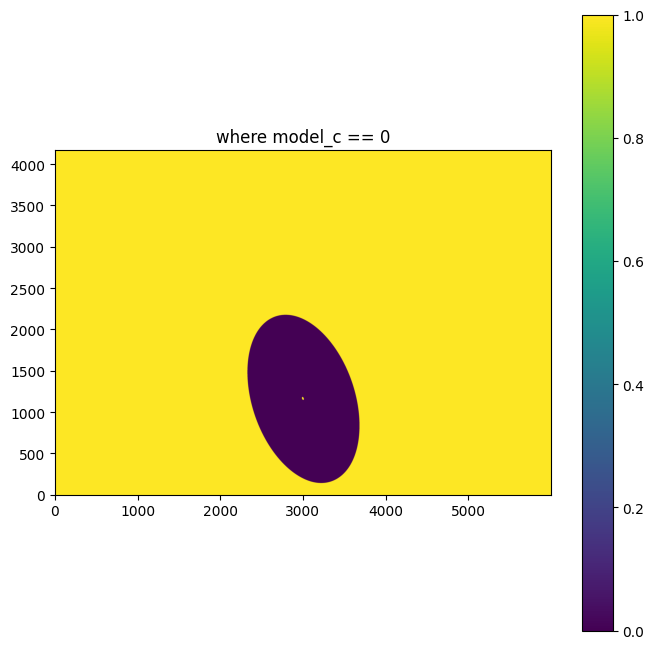

In [ ]:
plt.figure(figsize=(8, 8))
plt.imshow((model_c == 0), origin="lower")
plt.title("where model_c == 0")
plt.colorbar()
plt.show()

In [ ]:
h, w = resid.shape
regions = {
    "TL": resid[:h//2, :w//2],
    "TR": resid[:h//2, w//2:],
    "BL": resid[h//2:, :w//2],
    "BR": resid[h//2:, w//2:],
}

for name, arr in regions.items():
    vals = arr[np.isfinite(arr)]
    print(name,"med=" ,np.nanmedian(vals), "Mean=",np.nanmean(vals), "Std=",np.nanstd(vals))

[06:00:51] TL med= 0.2217385470867157 Mean= 0.2612973166626727 Std= 0.13888234705031896
[06:00:52] TR med= 0.6312385499477386 Mean= 1.1735555489942402 Std= 4.864231488558002
[06:00:52] BL med= 0.22152069211006165 Mean= 0.25258800276756904 Std= 0.10004204881266178
[06:00:52] BR med= 0.5938390493392944 Mean= 0.9762789360755036 Std= 0.999209915156255
